In [4]:
#import user modules
#--- MATPLOTLIB
#import user modules
#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset


import sys
my_path = "../../Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

from fit_funcs import *
import costfun.costfun as cost
import utils.figures as fig_help
import utils.tools as tools
from RandomMatrixTheory import goe
from Quad_tools import *

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)

import itertools
matplotlib.rcParams['mathtext.fontset'] = 'cm'
# plt.rcParams["mathtext.fontset"] = "cm"
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}

%matplotlib inline
colors_ls = (list(mcolors.TABLEAU_COLORS)[:200])
colors_ls_cyc = itertools.cycle(colors_ls)

markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   


# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import erf
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import gamma as gamma_fun
from scipy.special import lambertw
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
from scipy.interpolate import UnivariateSpline as InterpolateSpline
from scipy.interpolate import make_interp_spline as make_spline
from scipy.interpolate import splrep, splev
 
# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists

DIM = 1
modello = 'RP'


def base_dir(model, d, BC = 1):
    """
    Base directory for input model for d-dimension
    """
    dirx = f"../results/{model}/" + (f"" if model == 'PLRB' or model == 'RP' else  f"dim={d}/") + ( '' if model == 'RP' else (f"PBC/" if BC else f"OBC/") )
    return dirx

print(base_dir(modello, DIM))
%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}

/Users/rafal.swietek/Projects/CODES/QHamSolver/Quadratic/Jupyter_Python
/Users/rafal.swietek/opt/anaconda3/lib/python39.zip
/Users/rafal.swietek/opt/anaconda3/lib/python3.9
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/lib-dynload

/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/aeosa
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/locket-0.2.1-py3.9.egg
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/IPython/extensions
/Users/rafal.swietek/.ipython
../../Python/
../results/RP/


## TESTS

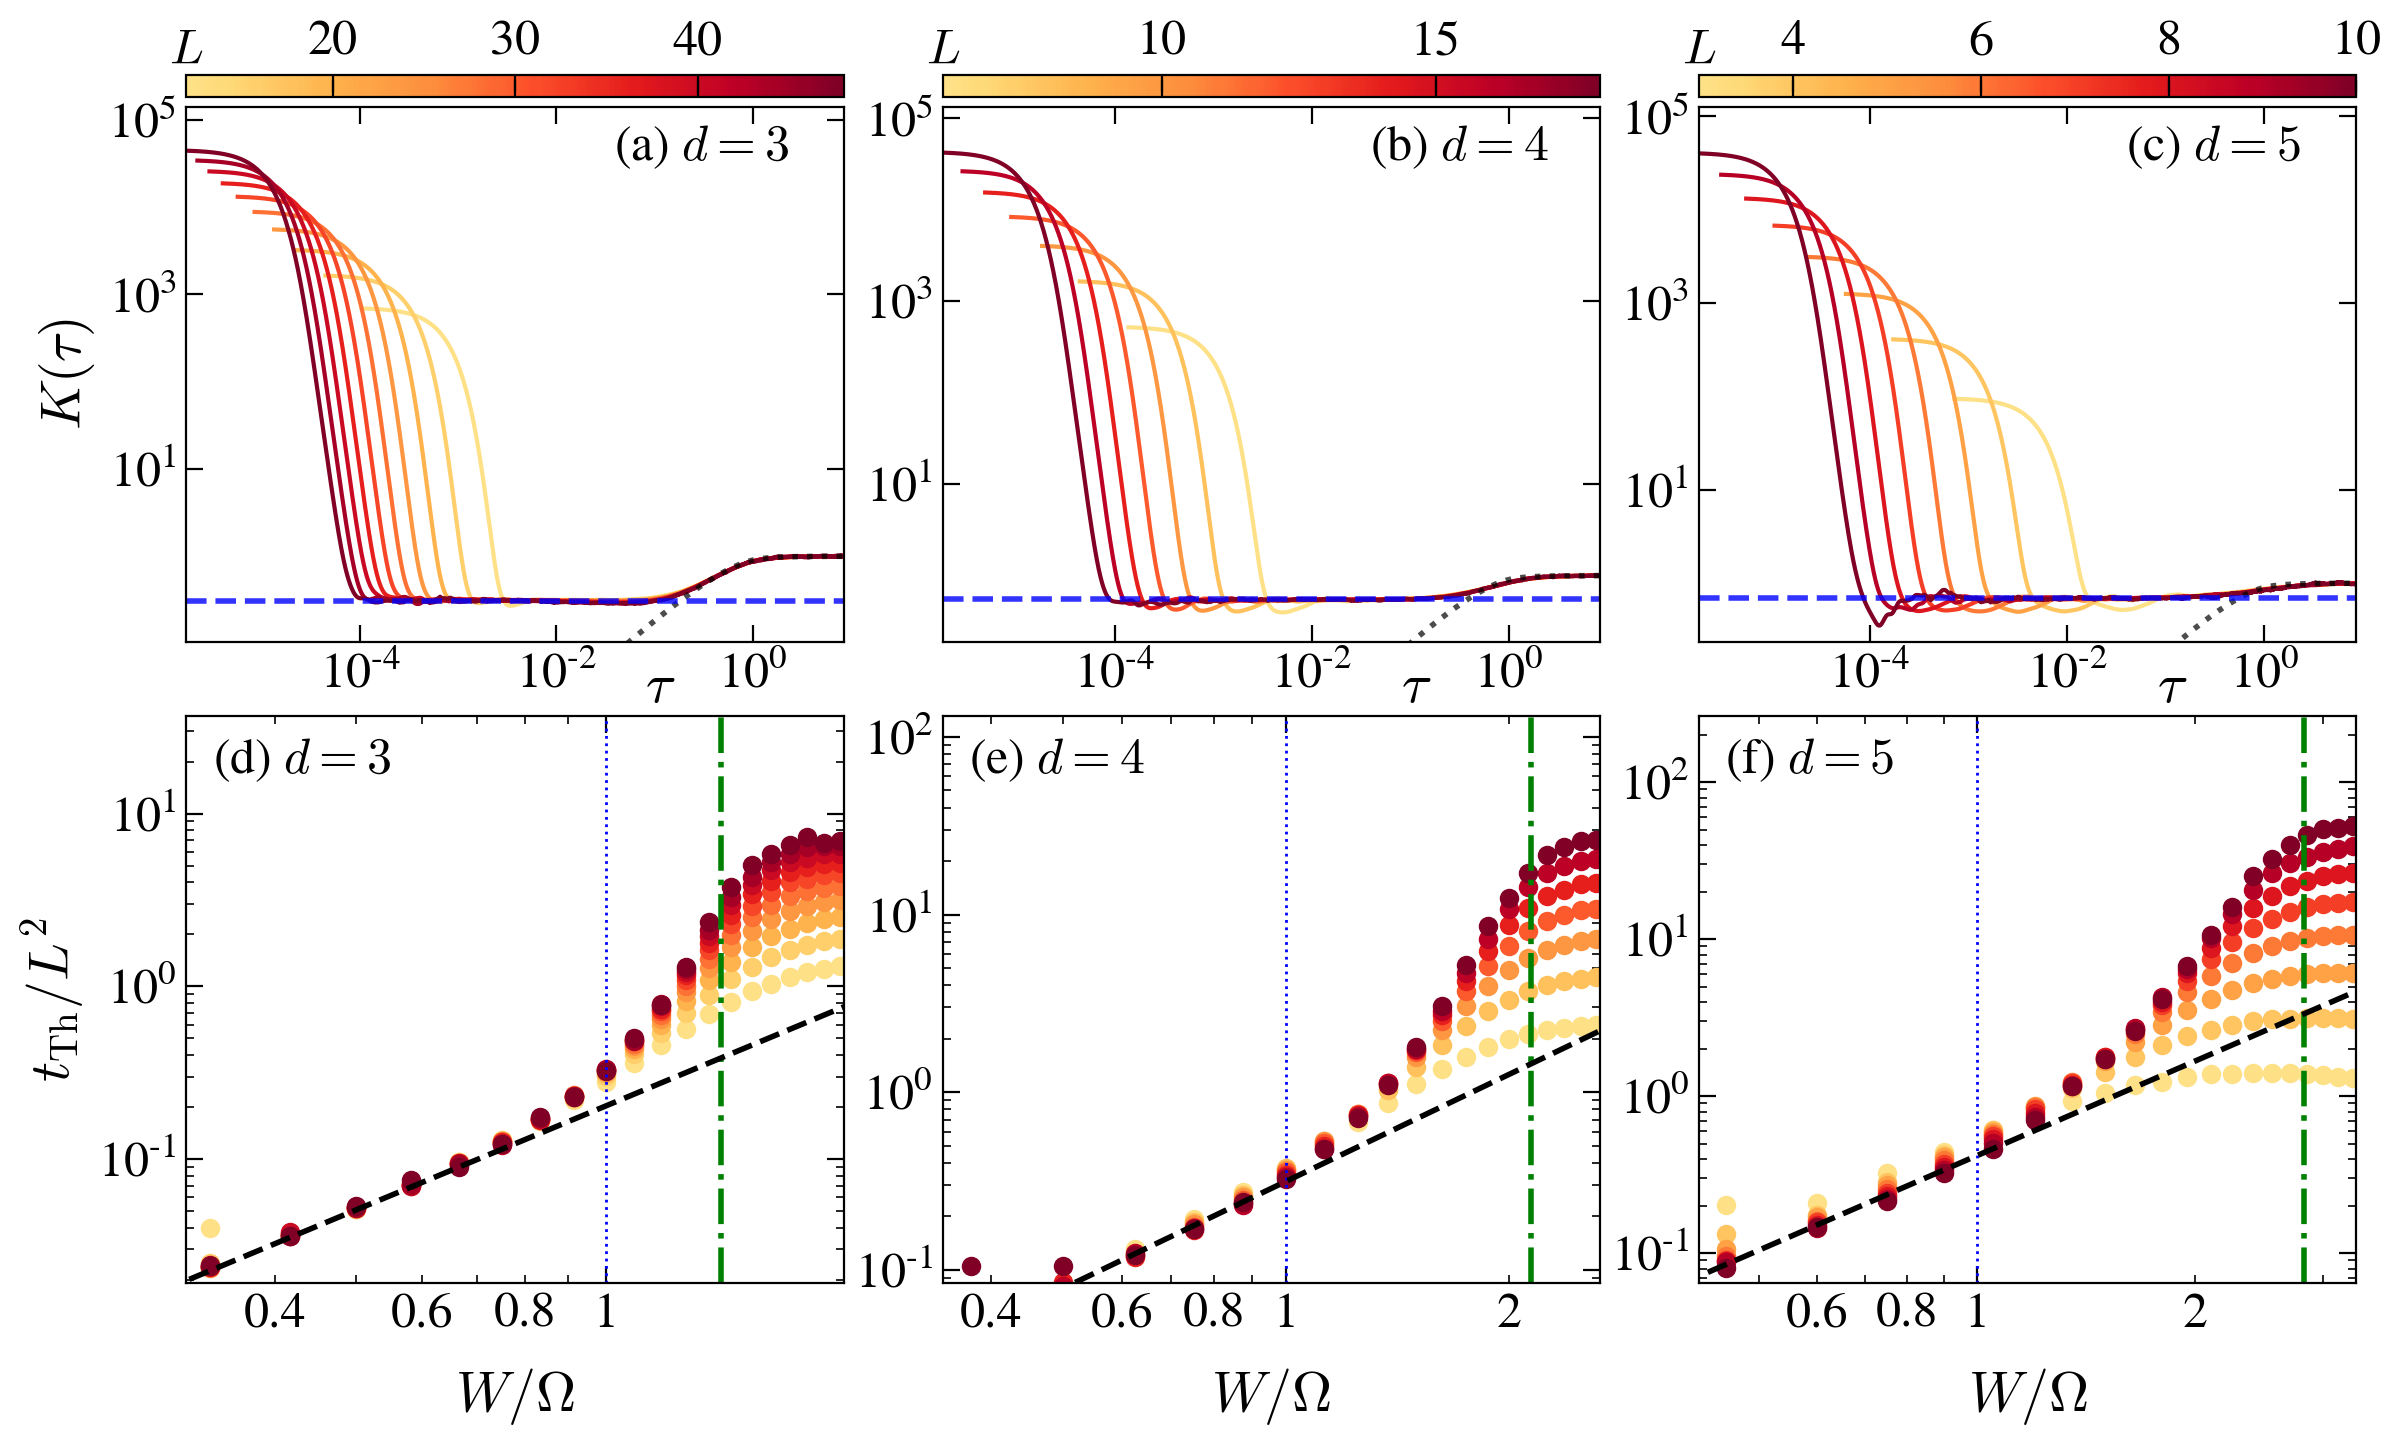

In [5]:

from mpl_toolkits.axes_grid1 import make_axes_locatable
L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'Anderson'


DIM = 3
prefix = base_dir(model=modello, d=DIM) + 'SpectralFormFactor/'

if DIM == 3:    sizes = np.arange(12, 49, 4)
elif DIM == 4:  sizes = np.arange(6, 19, 1)
elif DIM == 5:  sizes = np.arange(3, 11, 1)

fig, axis = plt.subplots( nrows=2, ncols=3, figsize=(14,8), dpi = 200, sharex=False)
axis = axis.flatten()




r_idx = 5
corr = 0
Ws = [2, 6, 10, 16]
# Ws = [6, 15, 39, 75]
if DIM == 3:    Ws = [4, 10, 16, 24]
elif DIM == 4:  Ws = [6, 20, 34, 46]
elif DIM == 5:  Ws = [8, 15, 57, 75]
else: Ws = []
labs = ["(a)", "(b)", "(c)", "(d)"]

dimss = [3, 4, 5]
Ws = [16, 34, 57]

W_crit = [16.54, 34.3, 56.5]
nuus = [1.57, 0.98, 0.84]

compress = [0.31, 0.56, 0.7]
cut = 0.1
window = 100
for iia, DIM in enumerate(dimss):
    
    folder = f'./thouless time/Anderson/d=%d/'%DIM
    Ws = [16, 34, 57]
    Wx = Ws[iia]
    prefix = base_dir(model=modello, d=DIM) + 'SpectralFormFactor/'
    if DIM == 3:    sizes = np.arange(12, 49, 4)
    elif DIM == 4:  sizes = np.arange(6, 19, 2)
    elif DIM == 5:  sizes = np.arange(3, 11, 1)
        
    norm = matplotlib.colors.Normalize(vmin=min(sizes),vmax=max(sizes) )

    # create a ScalarMappable and initialize a data structure
    upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.2, 1.0, 100))
    colors = np.vstack((upper))  
    mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

    s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
    s_m.set_array([])
    for ii, L in enumerate(sizes):
        
        col = s_m.to_rgba(L)
        name = prefix +  info(L=L, J=J, w=Wx, model=modello, ext='.hdf5')
    
        if exists(name):
            with h5py.File(name, "r") as file:
                tH = np.array(file.get('tH'))[0] / (2*np.pi)
                times = np.array(file.get('times'))[0]# / tH
                # sff = np.array(file.get('sff_eps'))[:,-1]
                # sff = np.array(file.get('sff_raw'))[0]
                sff = np.array(file.get('sff_eta'))[:,-3]
                sff = tools.remove_fluctuations(sff, bucket_size=window)[window//2:-window//2]
                times = times[window//2:-window//2]
                
                # sff = np.log10( sff / goe.spectral_form_factor(times))
                axis[iia].plot(times, sff, color=col, label=r"$L=%d$"%L)
        else:
            print(name)       
    axis[iia].plot(times, goe.spectral_form_factor(times), ls=':', color='k', lw=2, alpha=0.7)
    axis[iia].axhline(y=compress[iia], ls='--', color='blue', lw=2, alpha=0.8)
    axis[iia].set_xlim(min(times), max(times))
    axis[iia].xaxis.set_label_coords(0.72, -0.04)
    
    fig_help.set_plot_elements(axis[iia], ylabel=r"$K(\tau)$" if iia == 0 else "", xlabel=r"$\tau$", font_size=18, set_legend=0, xscale='log', yscale='log')
    # fig_help.set_legend(axis[iia], loc='upper right', fontsize=17)

    Ws = [2, 6, 10, 16]
    if DIM == 3:    Ws = np.arange(4, 26, 1);   Wmin = 3.9; Wmax = 24
    elif DIM == 4:  Ws = np.arange(6, 51, 2);   Wmin = 5.9; Wmax = 44
    elif DIM == 5:  Ws = np.arange(9, 76, 3);   Wmin = 8.9; Wmax = 68
    else: Ws = []
    
    for ii, L in enumerate(sizes):
        
        col = s_m.to_rgba(L)
        name_out = folder + f'_L=%d_eps=%.2f.hdf5'%(L, 0.5)
        
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                Ws = np.array(file.get('disorder'))
                indices = np.logical_and(Ws >= Wmin, Ws < Wmax)
                # print(indices)W
                Ws = Ws[indices]
                idx_wc = np.argmin(np.abs(Ws - W_crit[iia]))
                
                bandwidth = 4*(DIM)# + Ws
                # bandwidth = np.sqrt(2*(DIM) + Ws**2/12)
                Ws = Ws / bandwidth
                tH = np.array(file.get('heisenberg time'))[indices]
                thouless = np.array(file.get('thouless time'))[indices] / L**2
        else:
            thouless = np.zeros(Ws.shape); thouless.fill(np.nan)
            for iiw, Wx in enumerate(Ws):
                name = prefix +  info(L=L, J=J, w=Wx, model=modello, ext='.hdf5')
            
                if exists(name):
                    with h5py.File(name, "r") as file:
                        tH = np.array(file.get('tH'))[0]
                        sff = np.array(file.get('sff_eta'))[:,-3]
                        times = np.array(file.get('times'))[0]
                        
                        sff = tools.remove_fluctuations(sff, bucket_size=window)[window//2:-window//2]
                        times = times[window//2:-window//2]
                        
                        diff = np.log10( sff / goe.spectral_form_factor(times))
                        idx = np.argmin( np.abs(diff - cut) )
                        # thouless[iia] = times[idx] * tH[iia] / L**2
                        thouless[iiw] = times[idx] * tH / L**2
                else:
                    print(name)       
        axis[3+iia].scatter(Ws, thouless, color=col)
        
    fig_help.set_plot_elements(axis[3+iia], ylabel=r"$t_{\rm Th}/L^2$" if iia == 0 else "", xlabel=r"$W / \Omega$", font_size=18, set_legend=0, xscale='log', yscale='log')
    
    _bandwidth_wc = 4*(DIM)# + W_crit[iia]
    # _bandwidth_wc = np.sqrt(2*(DIM) + (W_crit[iia]**2)/12)
    axis[3+iia].axvline(x=W_crit[iia] / _bandwidth_wc, ls='-.', color='green', lw=2)
    axis[3+iia].axvline(x=1, ls=':', color='blue', lw=1)
    
    cbar = None

    divider = make_axes_locatable(axis[iia])
    cax = divider.new_vertical(size = '4%', pad = 0.05)

    fig.add_axes(cax)
    cbar = fig.colorbar(s_m, cax = cax, orientation = 'horizontal')
    cax.xaxis.set_ticks_position('top')
    cax.xaxis.set_label_position('top')
    # cax.xaxis.set_label_coords(-0.06, 0.05)
    
    cbar.set_label(r"$L$", fontsize=18)
    cax.tick_params(axis='both', which='major', direction="in",length=6, labelsize=18, bottom=True, top=True, left=True, right=True)
    cax.xaxis.set_label_coords(0.0, 1.55)
    
    z = np.linspace(min(Ws)-1, max(Ws)+1, 1000)
    idx = np.argmin(np.abs(Ws[4] - z))
    # # print(nuus[iia], (DIM-2)*nuus[iia])
    # y = 1 / np.abs(z - W_crit[iia])**( (DIM) )
    # axis[3+iia].plot(z, y / y[idx] * thouless[8], lw=2, color='k')
    
    y = (z)**2
    axis[3+iia].plot(z, y / y[idx] * thouless[4], lw=2, color='k', ls='--')

    # z = np.linspace(min(Ws), max(Ws), 1000)
    # # idx1 = np.argmin(np.abs(Ws[4] - z))
    # # idx2 = np.argmin(np.abs(Ws[12] - z))
    # _b = (Ws[4] - Ws[9]) / np.log(thouless[4] / thouless[9])
    # _a = thouless[4] * np.exp(-Ws[4] / _b)
    # y = _a * np.exp(z / _b)
    # axis[3+iia].plot(z, y, lw=2, color='green', ls='-.')
    
    # axis[3+iia].set_ylim(8e-3, 7e1)
    axis[3+iia].set_xlim(min(Ws) - (Ws[1] - Ws[0])/4, max(Ws) +  (Ws[1] - Ws[0])/4)
    axis[3+iia].set_ylim(0.8 * min(thouless), 5 * max(thouless))
    axis[3+iia].xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%g"%x ))
    axis[3+iia].xaxis.set_minor_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: "%g"%x if pos%2==0 else "" ))

axis[0].annotate(r"(a) $d=3$", xy=(0.65, 0.9), fontsize=18, xycoords='axes fraction')
axis[1].annotate(r"(b) $d=4$", xy=(0.65, 0.9), fontsize=18, xycoords='axes fraction')
axis[2].annotate(r"(c) $d=5$", xy=(0.65, 0.9), fontsize=18, xycoords='axes fraction')
axis[3].annotate(r"(d) $d=3$", xy=(0.04, 0.9), fontsize=18, xycoords='axes fraction')
axis[4].annotate(r"(e) $d=4$", xy=(0.04, 0.9), fontsize=18, xycoords='axes fraction')
axis[5].annotate(r"(f) $d=5$", xy=(0.04, 0.9), fontsize=18, xycoords='axes fraction')

axis[0].set_ylim(compress[0]/3, None)
axis[1].set_ylim(compress[1]/3, None)
axis[2].set_ylim(compress[2]/3, None)

fig.subplots_adjust(wspace=0.15, hspace=0.13)
plt.savefig("FigThouless.pdf", bbox_inches = 'tight', padding=0.02)

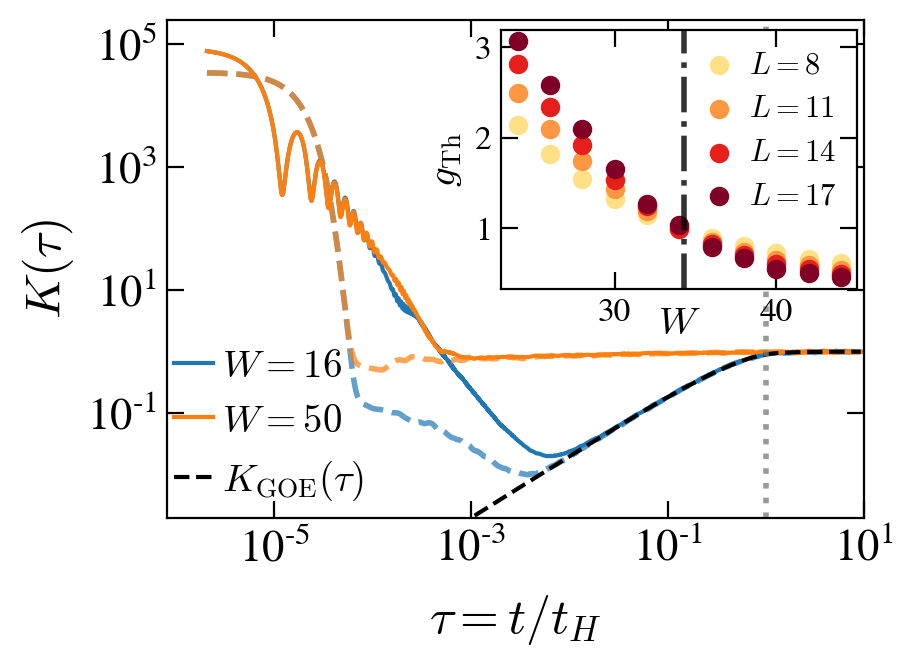

In [6]:
L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'Anderson'


DIM = 4
prefix = base_dir(model=modello, d=DIM) + 'SpectralFormFactor/'

if DIM == 3:    sizes = np.arange(12, 49, 8)
elif DIM == 4:  sizes = np.arange(8, 19, 3)
elif DIM == 5:  sizes = np.arange(3, 11, 1)

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4.5,3.3), dpi = 200, sharex=False, sharey=False)

r_idx = 5
corr = 0
Ws = [2, 6, 10, 16]
# Ws = [6, 15, 39, 75]
if DIM == 3:    Ws = [6, 24]; L = 44
elif DIM == 4:  Ws = [16, 50]; L = 17
elif DIM == 5:  Ws = [27, 75]; L = 8
else: Ws = []
labs = ["(a)", "(b)", "(c)", "(d)"]

cut = 0.1
window = 50
for iia, Wx in enumerate(Ws):

    name = prefix +  info(L=L, J=J, w=Wx, model=modello, ext='.hdf5')

    if exists(name):
        with h5py.File(name, "r") as file:
            tH = np.array(file.get('tH'))[0] / (2*np.pi)
            times = np.array(file.get('times'))[0]# / tH
            # sff = np.array(file.get('sff_eps'))[:,-1]
            sff = np.array(file.get('sff_raw'))[0]
            # sff = np.array(file.get('sff_eta'))[:,0]
            sff = tools.remove_fluctuations(sff, bucket_size=window)[window//2:-window//2]
            times = times[window//2:-window//2]
            
            # sff = np.log10( sff / goe.spectral_form_factor(times))
            p = axis.plot(times, sff, label=r"$W=%g$"%Wx)
            
            sff = np.array(file.get('sff_eta'))[:,-3]
            sff = tools.remove_fluctuations(sff, bucket_size=window)[window//2:-window//2]
            axis.plot(times, sff, ls='--', lw=2, alpha=0.7, color=p[0].get_color())
    else:
        print(name)       
axis.plot(times, goe.spectral_form_factor(times), ls='--', color='k', label=r"$K_{\rm GOE}(\tau)$")
# axis.axhline(y=cut, ls='--', color='k')
fig_help.set_plot_elements(axis, ylabel=r"$K(\tau)$", xlabel=r"$\tau=t/t_H$", font_size=16, set_legend=1, xscale='log', yscale='log')  
# fig_help.set_legend(axis, loc='lower left', fontsize=14)
axis.legend(frameon=False, fontsize=14, loc='lower left', handletextpad=0.25, handlelength = 1., bbox_to_anchor=(-0.04, -0.04))

axis.set_ylim(2e-3, None)
axis.set_xlim(8e-7, 10)
axis.axvline(x=1, ls=':', lw=2, color='gray', alpha=0.8)

inset = axis.inset_axes([0.48, 0.46, 0.51, 0.52])


if DIM == 3:    Ws = np.arange(10, 23, 1)
elif DIM == 4:  Ws = np.arange(24, 45, 2)
elif DIM == 5:  Ws = np.arange(39, 75, 3)
else: Ws = []
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.2, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)
norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes) )
s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])

for iiL, L in enumerate(sizes):
    col = s_m.to_rgba(L)
    thouless = np.zeros(Ws.shape)
    for iia, Wx in enumerate(Ws):
        name = prefix +  info(L=L, J=J, w=Wx, model=modello, ext='.hdf5')

        if exists(name):
            with h5py.File(name, "r") as file:
                tH = np.array(file.get('tH'))[0] / (2*np.pi)
                times = np.array(file.get('times'))[0]# / tH
                # sff = np.array(file.get('sff_eps'))[:,-1]
                sff = np.array(file.get('sff_raw'))[0]
                # sff = np.array(file.get('sff_eta'))[:,0]
                sff = tools.remove_fluctuations(sff, bucket_size=window)[window//2:-window//2]
                times = times[window//2:-window//2]
                
                diff = np.log10( sff / goe.spectral_form_factor(times))
                idx = np.argmin( np.abs(diff - cut) )
                thouless[iia] = np.log(1 / times[idx])
        else:
            print(name) 
    
    inset.scatter(Ws, thouless, color=col, label=r"$L=%d$"%L)
    # print(thouless)
    
inset.axvline(x=34.3, ls='-.', lw=2, color='k', alpha=0.8)
inset.xaxis.set_label_coords(0.5, -0.07)
fig_help.set_plot_elements(inset, ylabel=r"$g_{\rm Th}$", xlabel=r"$W$", font_size=12, set_legend=0, xscale='linear', yscale='linear')  
fig_help.set_legend(inset, loc='upper right', fontsize=11)

plt.savefig("Fig_sff.pdf", bbox_inches = 'tight', padding=0.02)

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


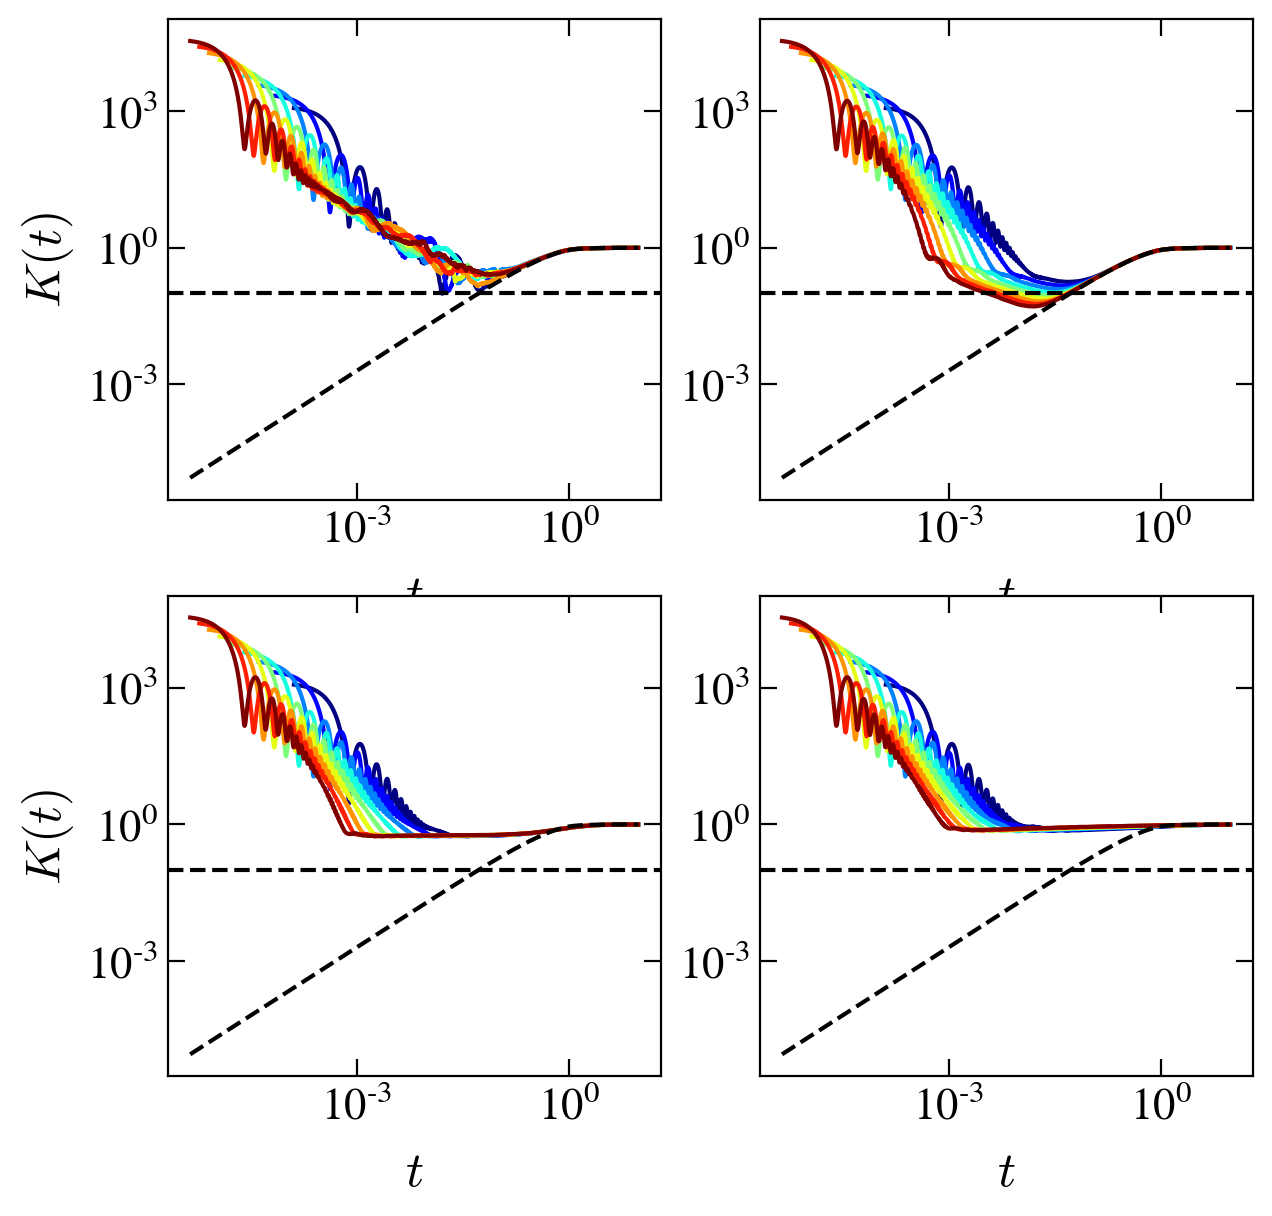

In [7]:
L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'Anderson'


DIM = 4
prefix = base_dir(model=modello, d=DIM) + 'SpectralFormFactor/'

if DIM == 3:    sizes = np.arange(12, 49, 4)
elif DIM == 4:  sizes = np.arange(6, 15, 1)
elif DIM == 5:  sizes = np.arange(3, 9, 1)

fig, axis = plt.subplots( nrows=2, ncols=2, figsize=(7,7), dpi = 200, sharex=False, sharey=False)
axis = axis.flatten()


norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])

r_idx = 5
corr = 0
Ws = [2, 6, 10, 16]
# Ws = [6, 15, 39, 75]
if DIM == 3:    Ws = [4, 10, 16, 24]
elif DIM == 4:  Ws = [6, 20, 34, 46]
elif DIM == 5:  Ws = [8, 15, 57, 75]
else: Ws = []
labs = ["(a)", "(b)", "(c)", "(d)"]

cut = 0.1
window = 50
for iia, Wx in enumerate(Ws):

    for ii, L in enumerate(sizes):
        
        col = s_m.to_rgba(L)
        name = prefix +  info(L=L, J=J, w=Wx, model=modello, ext='.hdf5')
    
        if exists(name):
            with h5py.File(name, "r") as file:
                tH = np.array(file.get('tH'))[0] / (2*np.pi)
                times = np.array(file.get('times'))[0]# / tH
                # sff = np.array(file.get('sff_eps'))[:,-1]
                sff = np.array(file.get('sff_raw'))[0]
                sff = tools.remove_fluctuations(sff, bucket_size=window)[window//2:-window//2]
                times = times[window//2:-window//2]
                
                # sff = np.log10( sff / goe.spectral_form_factor(times))
                axis[iia].plot(times, sff, color=col)
        else:
            print(name)       
    axis[iia].plot(times, goe.spectral_form_factor(times), ls='--', color='k')
    axis[iia].axhline(y=cut, ls='--', color='k')
    fig_help.set_plot_elements(axis[iia], ylabel=r"$K(t)$" if iia%2 == 0 else "", xlabel=r"$t$", font_size=16, set_legend=1, xscale='log', yscale='log')  

0.02
0.02
0.02
0.02
0.02
0.02


No handles with labels found to put in legend.


0.02
0.02
0.02
0.02
0.06
0.06
0.06
0.06
0.06
0.06


No handles with labels found to put in legend.


0.06
0.06
0.06
0.06
0.22
0.22
0.22
0.22
0.22
0.22
0.22


No handles with labels found to put in legend.


0.22
0.22
0.22
0.5
0.5
0.5
0.5
0.5
0.5
0.5
0.5
0.5


No handles with labels found to put in legend.


0.5


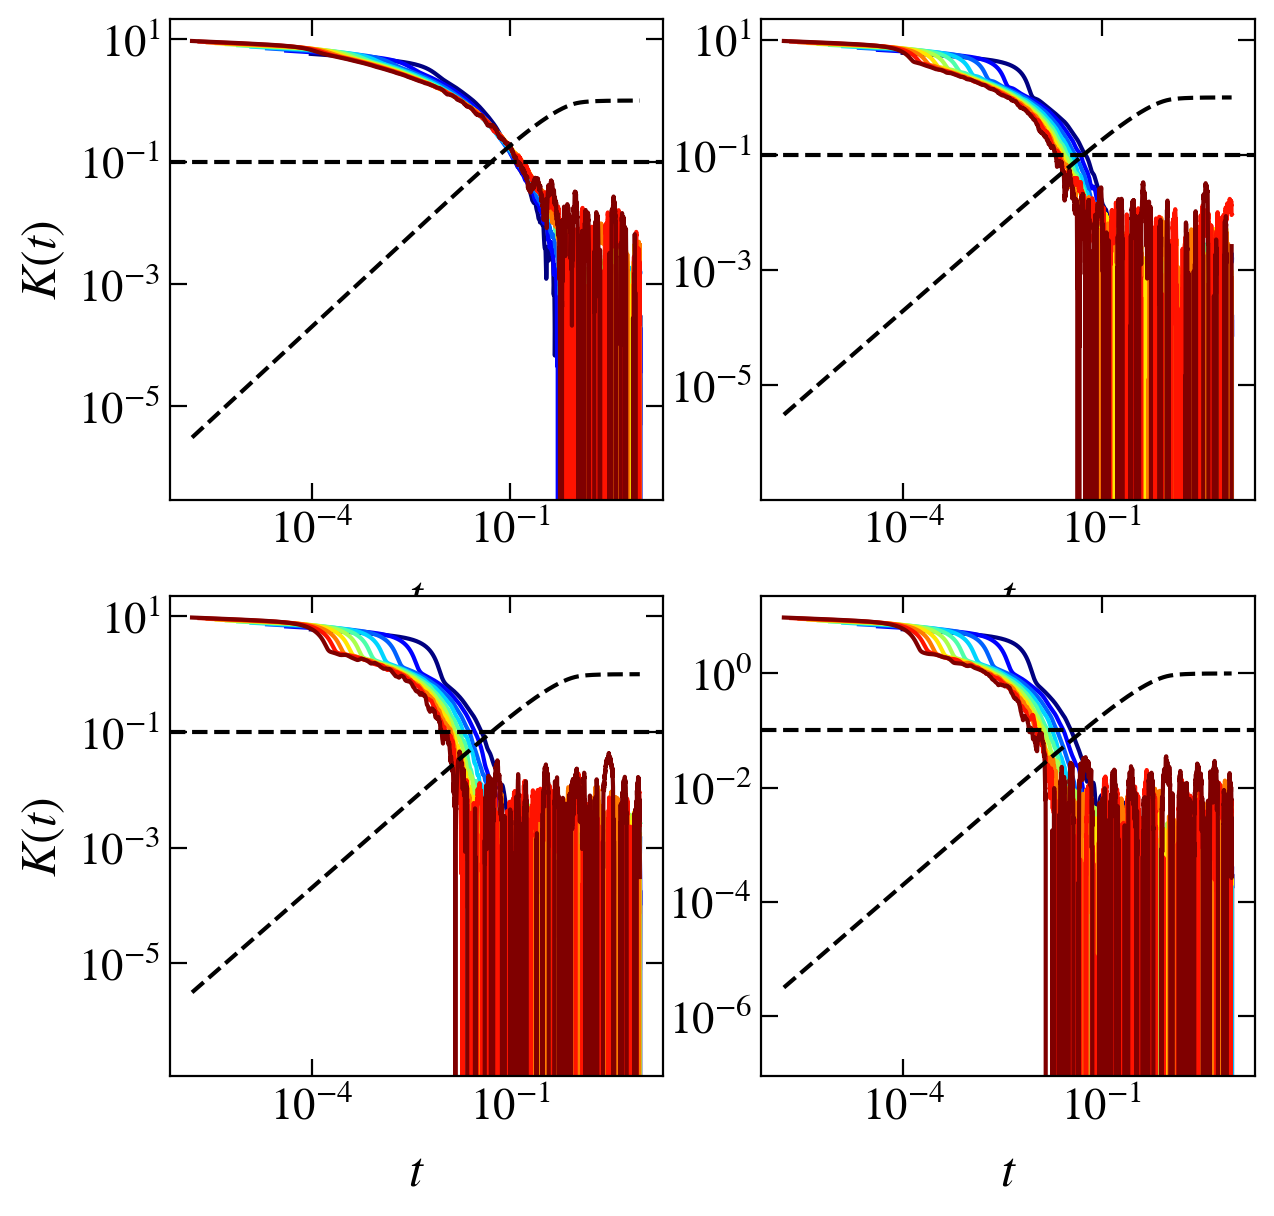

In [4]:
L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'Anderson'


DIM = 3
prefix = base_dir(model=modello, d=DIM) + 'SpectralFormFactor/'

if DIM == 3:    sizes = np.arange(12, 49, 4)
elif DIM == 4:  sizes = np.arange(6, 15, 1)
elif DIM == 5:  sizes = np.arange(3, 9, 1)

import matplotlib.pyplot as plt
fig, axis = plt.subplots( nrows=2, ncols=2, figsize=(7,7), dpi = 200, sharex=False, sharey=False)
axis = axis.flatten()


norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])

r_idx = 5
corr = 0
Ws = [2, 6, 10, 16]
Ws = [6, 15, 39, 75]
labs = ["(a)", "(b)", "(c)", "(d)"]

cut = 0.1
window = 50
beta_idx = [0, 2, 10, -1]

Wx = 5
# Ws = [6, 15, 39, 75]
if DIM == 3:    Wx = 10
elif DIM == 4:  Wx = 20
elif DIM == 5:  Wx = 30
else: Wx = 0

for iia, iieps in enumerate(beta_idx):
    ymin = 1e6
    for ii, L in enumerate(sizes):
        
        col = s_m.to_rgba(L)
        name = prefix +  info(L=L, J=J, w=Wx, model=modello, ext='.hdf5')
    
        if exists(name):
            with h5py.File(name, "r") as file:
                tH = np.array(file.get('tH_typ'))[0] / (2*np.pi)
                times = np.array(file.get('times'))[0]
                sff = np.array(file.get('sff_eps'))[:,iieps]
                sff = tools.remove_fluctuations(sff, bucket_size=window)[window//2:-window//2]
                times = times[window//2:-window//2]
                
                eps = np.array(file.get('energy_densities'))[0]
                print(eps[iieps])
                sff = np.log10( sff / goe.spectral_form_factor(times))
                axis[iia].plot(times, sff, color=col)
                if np.min(sff) < ymin: ymin = np.min(sff)
        else:
            print(name)       
    axis[iia].plot(times, goe.spectral_form_factor(times), ls='--', color='k')
    axis[iia].axhline(y=cut, ls='--', color='k')
    fig_help.set_plot_elements(axis[iia], ylabel=r"$K(t)$" if iia%2 == 0 else "", xlabel=r"$t$", font_size=16, set_legend=1, xscale='log', yscale='log')  
    # axis[iia].set_ylim(ymin/2, 1.2)

0.5 3 243 10000.0 10000.0
0.5 4 1024 10000.0 10000.0
0.5 5 3125 10000.0 10000.0
0.5 6 7776 9007.0 9566.0
0.5 7 16807 8786.0 9372.0
0.5 8 32768 2799.0 3132.0
0.5 9 59049 127.0 148.0


No handles with labels found to put in legend.


0.5 10 100000 27.0 38.0


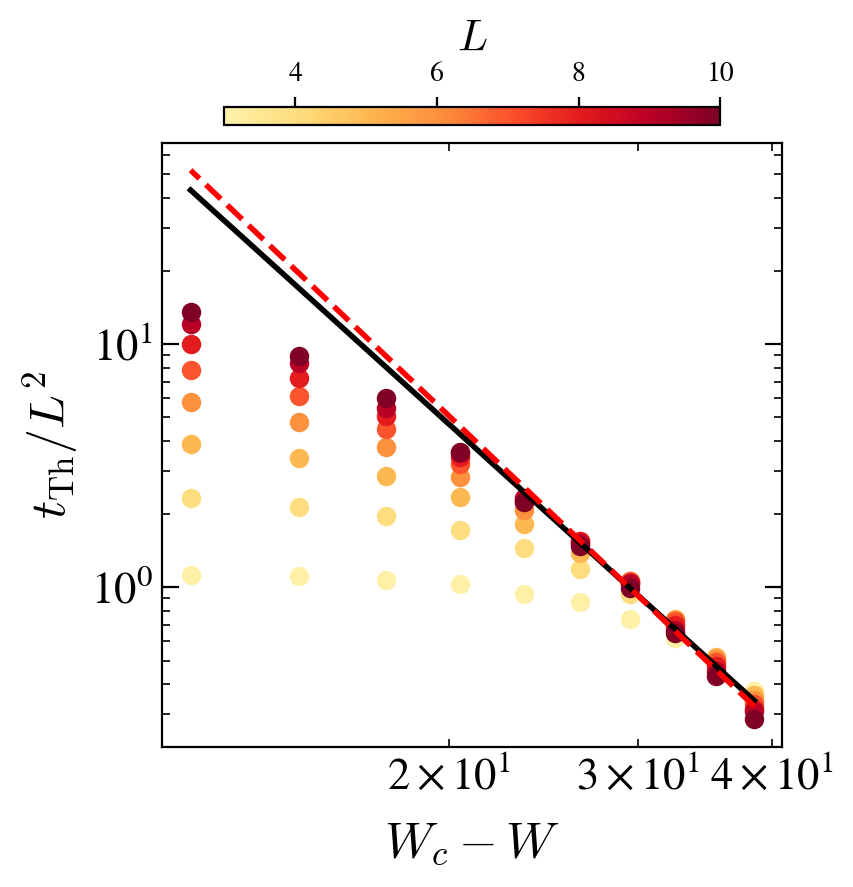

In [3]:
L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'Anderson'


DIM = 5
prefix = base_dir(model=modello, d=DIM) + 'SpectralFormFactor/'

if DIM == 3:    sizes = np.arange(12, 49, 4)
elif DIM == 4:  sizes = np.arange(6, 19, 1)
elif DIM == 5:  sizes = np.arange(3, 11, 1)

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,4), dpi = 200, sharex=False, sharey=False)
# axis = axis.flatten()


norm = matplotlib.colors.Normalize(vmin=min(sizes), vmax=max(sizes) )

# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])

r_idx = 5
corr = 0
Ws = [2, 6, 10, 16]
if DIM == 3:    Ws = np.arange(10, 16, 1);   Wmin = 10; Wmax = 15; W_crit = 16.54; nu = 1.57
elif DIM == 4:  Ws = np.arange(14, 31, 2);   Wmin = 16; Wmax = 30; W_crit = 34.3; nu = 0.98
elif DIM == 5:  Ws = np.arange(18, 46, 3);   Wmin = 20; Wmax = 45; W_crit = 56.5; nu = 0.84
else: Ws = []

labs = ["(a)", "(b)", "(c)", "(d)"]

window = 100
cut = 0.15
for eps in np.arange(0.5, 0.51, 0.02):
    folder = f'./thouless time/Anderson/d=%d/'%DIM
    for ii, L in enumerate(sizes):
        col = s_m.to_rgba(L)
        
        name_out = folder + f'_L=%d_eps=%.2f.hdf5'%(L, eps)
        
        if False and exists(name_out):
            with h5py.File(name_out, "r") as file:
                
                Ws = np.array(file.get('disorder'))
                indices = np.logical_and(Ws >= Wmin, Ws < Wmax)
                Ws = W_crit - Ws[indices]
                thouless = np.array(file.get('thouless conductivity'))[indices]
                tH = np.array(file.get('heisenberg time'))[indices]
                # Ws = np.array(file.get('disorder'))
        else:
            thouless = np.zeros(Ws.shape); thouless.fill(np.nan)
            tH = np.zeros(Ws.shape); tH.fill(np.nan)
            tH_typ = np.zeros(Ws.shape); tH_typ.fill(np.nan)
            gap_ratio = np.zeros(Ws.shape); gap_ratio.fill(np.nan)
            gap_ratio_500 = np.zeros(Ws.shape); gap_ratio_500.fill(np.nan)
            
            realizations = np.zeros(Ws.shape); realizations.fill(np.nan)
            
            for iia, Wx in enumerate(Ws):
                name = prefix +  info(L=L, J=J, w=Wx, model=modello, ext='.hdf5')
            
                if exists(name):
                    with h5py.File(name, "r") as file:
                        tH[iia] = np.array(file.get('tH'))[0]
                        tH_typ[iia] = np.array(file.get('tH_typ'))[0]
                        gap_ratio[iia] = np.array(file.get('r_500'))[0]
                        gap_ratio_500[iia] = np.array(file.get('r_D_2'))[0]
                        
                        R = np.array(file.get('realisations'))[0]
                        realizations[iia] = R
                        E = np.array(file.get('energy_densities'))[0]
                        idxE = np.argmin( np.abs(E - eps) )
                        # print(L, Wx, R)
                        times = np.array(file.get('times'))[0]
                        # sff = np.array(file.get('sff_eps'))[:, idxE]
                        sff = np.array(file.get('sff_eta'))[:,-2]
                        
                        sff = tools.remove_fluctuations(sff, bucket_size=window)[window//2:-window//2]
                        times = times[window//2:-window//2]
                        
                        diff = np.log10( sff / goe.spectral_form_factor(times))
                        idx = np.argmin( np.abs(diff - cut) )
                        # thouless[iia] = times[idx] * tH[iia] / L**2
                        thouless[iia] = np.log(1/times[idx])
                else:
                    print(name)       
            # os.makedirs(folder, exist_ok=True)
            # # name_out = folder + f'_L=%d_eps=%.2f.hdf5'%(L, eps)
            # hf = h5py.File(name_out, 'w')
            # hf.create_dataset('disorder',                Ws.shape, data = Ws)
            # hf.create_dataset('thouless time',           thouless.shape,   data = np.exp(-thouless) * tH )
            # hf.create_dataset('thouless conductivity',   thouless.shape,   data = thouless)
            # hf.create_dataset('heisenberg time',         tH.shape,         data = tH)
            # hf.create_dataset('typical heisenberg time', tH_typ.shape,     data = tH_typ)
            # hf.create_dataset('gap ratio',               gap_ratio.shape,  data = gap_ratio)
            # hf.create_dataset('gap ratio 500',           gap_ratio_500.shape,  data = gap_ratio_500)
            # hf.close()
        # axis.scatter(Ws, thouless, color=col)
        # gTh = thouless / tH /L**2
        gTh = np.exp(-thouless) * tH /L**2
        axis.scatter(W_crit - Ws, gTh, color=col)
        
        print(eps, L, L**DIM, min(realizations), max(realizations))
    
    # Ws = W_crit - Ws
    # z = W_crit - np.linspace(min(Ws), max(Ws), 1000)
    # # axis.plot(z, 1/z, lw=2, color='k')
    # idx = np.argmin(np.abs(Ws[4] - z))
    
    y = 1/(W_crit - Ws)**(DIM-1)
    axis.plot(W_crit - Ws, y / y[3] * gTh[3], lw=2, color='k')
    
    y = 1/(W_crit - Ws)**( (DIM) * nu )
    axis.plot(W_crit - Ws, y / y[3] * gTh[3], lw=2, color='red', ls='--')
    
    # y = (z)**(2)
    # axis.plot(z, y / y[idx] * gTh[8], lw=2, color='gray', ls='--')
    
    # z = np.linspace(min(Ws), max(Ws), 1000)
    # idx1 = np.argmin(np.abs(Ws[6] - z))
    # idx2 = np.argmin(np.abs(Ws[10] - z))
    # _b = (Ws[6] - Ws[10]) / np.log(gTh[6] / gTh[10])
    # _a = gTh[6] * np.exp(-Ws[6] / _b)
    # y = _a * np.exp(z / _b)
    # axis.plot(z, y, lw=2, color='green', ls='-.')
    # fig_help.set_plot_elements(axis, ylabel=r"$g_{\rm Th}$", xlabel=r"$W$", font_size=16, set_legend=1, xscale='linear', yscale='linear')  
    fig_help.set_plot_elements(axis, ylabel=r"$t_{\rm Th}/L^2$", xlabel=r"$W_c-W$", font_size=16, set_legend=1, xscale='log', yscale='log')
    # axis.set_xlim(0.5 * min(Ws), 1.1 * max(Ws))
    # axis.set_ylim(0.2 * min(gTh), 5 * max(gTh))
    cbar_ax = axis.inset_axes([0.1, 1.03, 0.8, 0.03])
    # fig.colorbar(im, cax=cbar_ax)
    cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'horizontal')
    cbar.set_label(r"$L$", fontsize=16)
    cbar_ax.xaxis.set_ticks_position('top')
    cbar_ax.xaxis.set_label_position('top')

In [80]:
11**5

161051

3 54 [10000]
4 54 [10000]
5 54 [10000]
6 54 [9580]
7 54 [8897]
8 54 [3133]
9 54 [142]
10 54 [31]


No handles with labels found to put in legend.
No handles with labels found to put in legend.


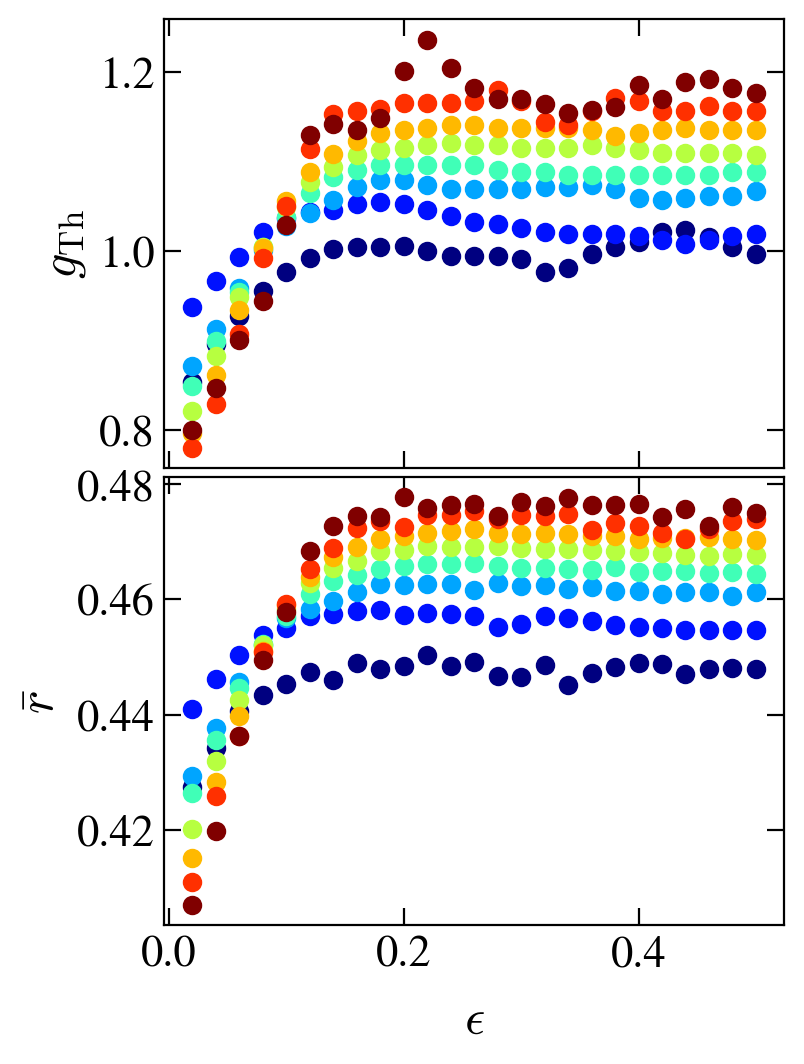

In [187]:
L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'Anderson'


DIM = 5
prefix = base_dir(model=modello, d=DIM) + 'SpectralFormFactor/'

sizes = np.arange(12, 49, 4)
sizes = np.arange(6, 19, 1)
sizes = np.arange(3, 11, 1)

fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4,6), dpi = 200, sharex=True, sharey=False)
# axis = axis.flatten()


norm = matplotlib.colors.Normalize(
        vmin=min(sizes),
        vmax=max(sizes))
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
s_m.set_array([])

r_idx = 5
corr = 0
Ws = [2, 6, 10, 16]
Ws = np.arange(1, 26, 1)
# Ws = np.arange(2, 51, 2)
labs = ["(a)", "(b)", "(c)", "(d)"]


Wx = 54
window = 100
cut = 0.15
for ii, L in enumerate(sizes):
    
    col = s_m.to_rgba(L)
    
    name = prefix +  info(L=L, J=J, w=Wx, model=modello, ext='.hdf5')

    if exists(name):
        with h5py.File(name, "r") as file:
            tH = np.array(file.get('tH'))[0]
            eps = np.array(file.get('energy_densities'))[0]
            
            R = np.array(file.get('realisations'))[0]
            print(L, Wx, R)
            
            gap_ratio = np.zeros(eps.shape)
            thouless = np.zeros(eps.shape)
            for iib, beta in enumerate(eps):
                times = np.array(file.get('times'))[0]
                sff = np.array(file.get('sff_eps'))[:,iib]
                sff = tools.remove_fluctuations(sff, bucket_size=window)[window//2:-window//2]
                times = times[window//2:-window//2]
                
                diff = np.log10( sff / goe.spectral_form_factor(times))
                idx = np.argmin( np.abs(diff - cut) )
                thouless[iib] =  np.log(1 / times[idx])
                gap_ratio[iib] = np.array(file.get('gap_ratio density'))[0,iib]
            
            axis[0].scatter(eps, thouless, color=col)
            axis[1].scatter(eps, gap_ratio, color=col)
    else:
        print(name)       
    
    
fig_help.set_plot_elements(axis[0], ylabel=r"$g_{\rm Th}$", xlabel=r"", font_size=16, set_legend=1, xscale='linear', yscale='linear')  
fig_help.set_plot_elements(axis[1], ylabel=r"$\bar{r}$", xlabel=r"$\epsilon$", font_size=16, set_legend=1, xscale='linear', yscale='linear')  

fig.subplots_adjust(wspace = 0.02, hspace=0.02)

No handles with labels found to put in legend.
No handles with labels found to put in legend.


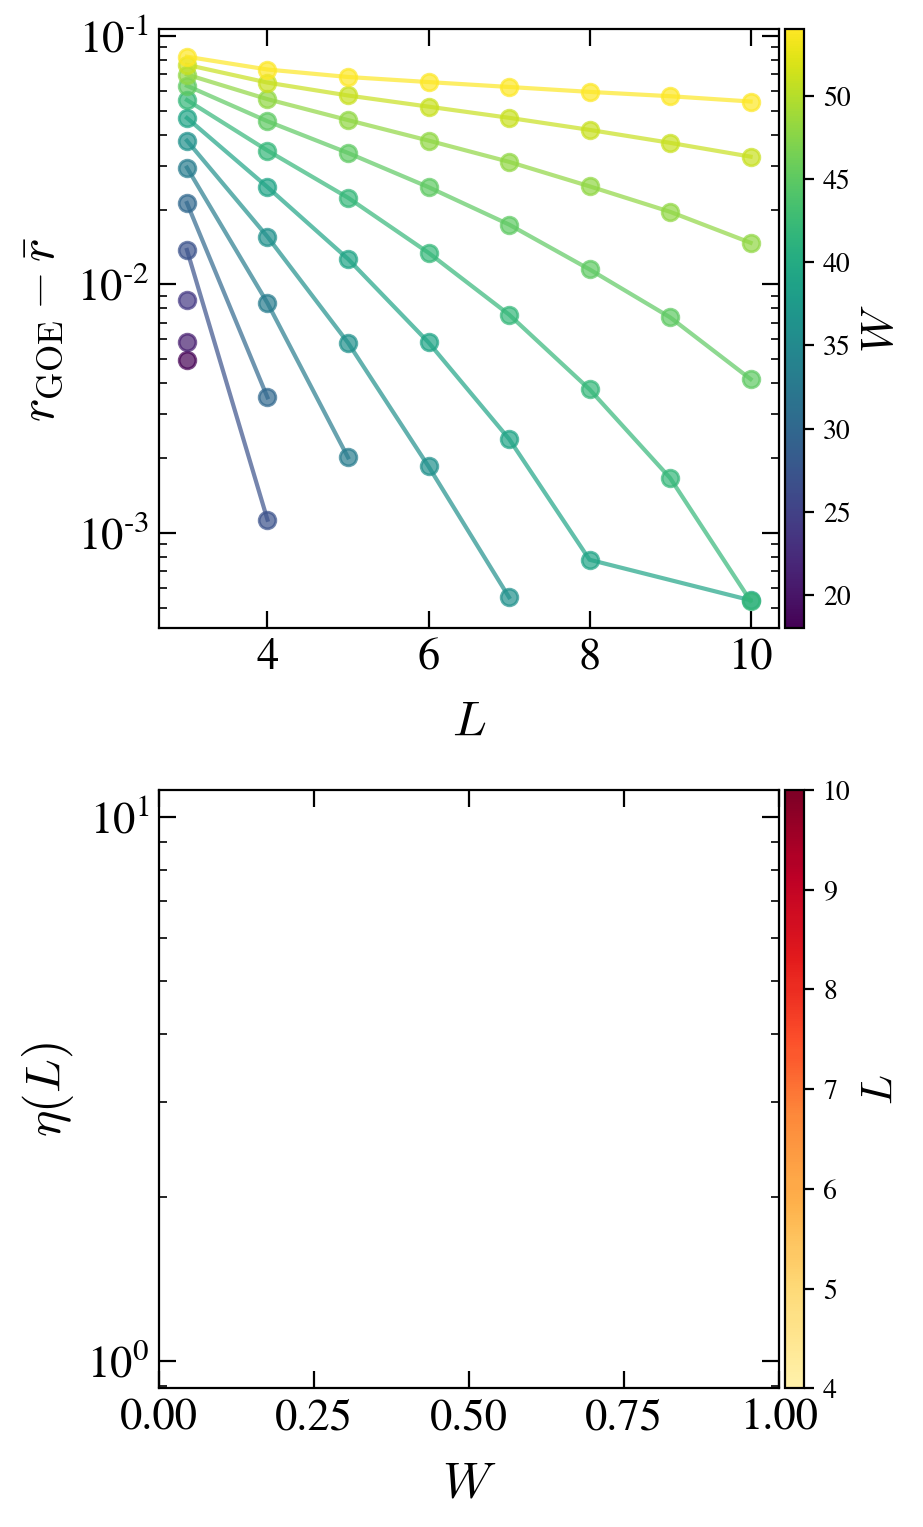

In [197]:
L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'Anderson'


DIM = 5
prefix = base_dir(model=modello, d=DIM) + 'SpectralFormFactor/'

if DIM == 3:    sizes = np.arange(12, 49, 4)
elif DIM == 4:  sizes = np.arange(6, 19, 1)
elif DIM == 5:  sizes = np.arange(3, 11, 1)

# fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(4,4), dpi = 200, sharex=False, sharey=False)
# axis = axis.flatten()


norm = matplotlib.colors.Normalize(vmin=min(sizes), vmax=max(sizes) )

# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])

r_idx = 5
corr = 0
Ws = [2, 6, 10, 16]
if DIM == 3:    Ws = np.arange(11, 18, 1);   Wmin = 12; Wmax = 15; W_crit = 16.54; nu = 1.57
elif DIM == 4:  Ws = np.arange(14, 35, 2);   Wmin = 16; Wmax = 30; W_crit = 34.3; nu = 0.98
elif DIM == 5:  Ws = np.arange(18, 56, 3);   Wmin = 20; Wmax = 45; W_crit = 56.5; nu = 0.84
else: Ws = []

fig, axis = plt.subplots( nrows=2, ncols=1, figsize=(4,9), dpi = 200)

window = 100
eps = 0.5

def exp_fit_kurwa(V, a, xi):
    """Exponential function to fit and find decay rate"""
    return a * V**(-xi)
    # return 1 - 1 / (1 + a * 2**(-x * xi))

# wx_vals = np.arange(0.04, 0.51, 0.04)

norm = matplotlib.colors.Normalize(
        vmin=min(Ws),
        vmax=max(Ws))
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
s_m.set_array([])

etas = []
etas_fit = []
for ibsifusdf, wx in enumerate(Ws):
    col = s_m.to_rgba(wx)
    
    gap_ratio = np.zeros(sizes.shape)
    realis = np.zeros(sizes.shape)
    # ------------------------------------------------------------ ROZENZWEIG-PORTER
    for iiL, L in enumerate(sizes):
        dim = L**DIM
        counter = 0
        r = 0#np.zeros((45))
        
        name = prefix +  info(L=L, J=J, w=wx, model=modello, ext='.hdf5')
        if exists(name):
            with h5py.File(name, "r") as file:
                try:
                    # yy = np.array(file.get('gap_ratio density'))
                    # gap_ratio[iiL] = np.mean(yy)
                    gap_ratio[iiL] = ( np.array(file.get('r_D_2')) )
                    realis[iiL] = np.array(file.get('realisations'))
                except TypeError:
                    print(name, yy)
        else:
            print(name) 
            
    # print(wx, realis, gap_ratio)
    error = 5e-4#1/(realis)**1
    yy = np.abs(0.53071 - gap_ratio)
    indices = np.argwhere(yy > error)
    xx = sizes[indices]#**DIM
    yy = yy[indices]
    # print(wx, xx, yy)
    # if yy.size > 4:
    #     parsolo, pconv, fit_info, msg, _ = fit(exp_fit_kurwa,
    #                     xdata = xx,
    #                     ydata = yy,
    #                     full_output=True, maxfev=10000)
    #     A = parsolo[0]
    #     eta_fit = 1 / parsolo[1]
    #     if eta_fit > 1e6:
    #         eta_fit = np.nan
    #     etas_fit.append(eta_fit)
    #     # if (iig == 0 and gx > 1.0) or (iig and gx < 4):
    #     z = np.linspace(min(xx)-1, max(xx)+1, 1000)
    #     axis[0].plot(z, exp_fit_kurwa(z, *parsolo), color=col, ls='--', lw=2)
    axis[0].plot(xx, yy, color=col, marker='o', alpha=0.7)
    
    eta = 1 / (np.diff( np.log(yy) ) / np.diff(xx) / np.log(2))
    etas.append(eta)
    
cbar_ax = axis[0].inset_axes([1.01, 0.0, 0.03, 1])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$W$", fontsize=16)
# cbar_ax.xaxis.set_ticks_position('top')
# cbar_ax.xaxis.set_label_position('top')

etas_fit = np.array(etas_fit)
etas = np.transpose(np.array(etas))

norm = matplotlib.colors.Normalize(vmin=min(sizes[1:]), vmax=max(sizes[1:]) )

# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])
# for iiL, L in enumerate(sizes[1:]):
#     col = s_m.to_rgba(L)
#     axis[1].scatter(Ws, np.abs(etas[iiL]), color=col, marker='o', facecolor=col, alpha=0.7)  

# axis[1].scatter(Ws, np.abs(etas_fit), color='k', marker='s', facecolor='None')

# axis[0].set_xlim(min(sizes)-0.5, max(sizes)+0.5)

cbar_ax = axis[1].inset_axes([1.01, 0.0, 0.03, 1])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation = 'vertical')
cbar.set_label(r"$L$", fontsize=16)

# ax.set_ylim(0, 1.05)

# z = np.linspace(1.0, 3.01, 1000)
# ax.plot(z, 2/np.abs(2 - z), ls='-.', color='blue')
# ax.set_ylim(1, 3e2)
# z = np.linspace(0.5, 1.0, 1000)
# ax.plot(z, [1]*z.size, ls='-.', color='blue')
# # ax[1].scatter(gamma_vals, 1/(etas_NE / np.log(2)), color='red', marker='s', facecolor='None')

fig_help.set_plot_elements(axis[0], ylabel=r"$r_{\rm GOE}-\bar{r}$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
# fig_help.set_plot_elements(axis[1], ylabel=r"$\bar{r} - r_{\rm PE}$", xlabel=r"$L$", font_size=16, set_legend=1, xscale='linear', yscale='log')
fig_help.set_plot_elements(axis[1], ylabel=r"$\eta(L)$", xlabel=r"$W$", font_size=16, set_legend=1, xscale='linear', yscale='log')


fig.subplots_adjust(wspace = 0.27, hspace=0.27)

(23, 25) (23, 25) (25, 23)


Text(0.5, 1.0, '$\\langle r\\rangle$')

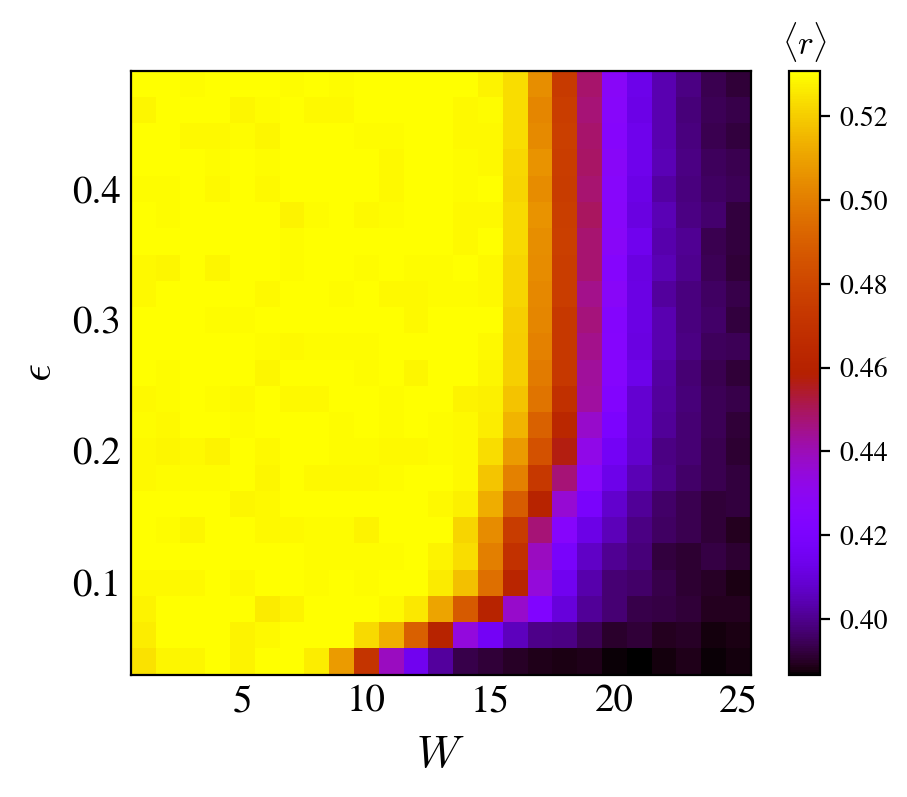

In [170]:

markers = itertools.cycle(markers_ls)

L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'Anderson'


DIM = 3
prefix = base_dir(model=modello, d=DIM) + 'SpectralFormFactor/'

if DIM == 3:    sizes = np.arange(12, 49, 4)
elif DIM == 4:  sizes = np.arange(6, 19, 1)
elif DIM == 5:  sizes = np.arange(3, 11, 1)

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,4), dpi = 200)

norm = matplotlib.colors.Normalize(vmin=min(sizes), vmax=max(sizes) )

# create a ScalarMappable and initialize a data structure
upper = plt.get_cmap('YlOrRd', 100)(np.linspace(0.1, 1.0, 100))
colors = np.vstack((upper))  
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

s_m = matplotlib.cm.ScalarMappable(cmap=mymap, norm=norm)
s_m.set_array([])

r_idx = 5
corr = 0
Ws = [2, 6, 10, 16]
if DIM == 3:    Ws = np.arange(1, 26, 1);   Wmin = 12; Wmax = 15; W_crit = 16.54; nu = 1.57; L = 48
elif DIM == 4:  Ws = np.arange(2, 51, 2);   Wmin = 16; Wmax = 30; W_crit = 34.30; nu = 0.98; L = 18
elif DIM == 5:  Ws = np.arange(3, 76, 3);   Wmin = 20; Wmax = 45; W_crit = 56.50; nu = 0.84; L = 10
else: Ws = []


energy_density = None
gap_ratio_density = []
for ii, wx in enumerate(Ws):
    name = prefix +  info(L=L, J=J, w=wx, model=modello, ext='.hdf5')
    if exists(name):
        with h5py.File(name, "r") as file:
            # gap_ratio = np.array(file.get('gap_ratio density'))
            E = np.array(file.get('energy_densities'))[0]
            E = E[1:-1]
            gap_ratio = np.array(file.get('gap_ratio density')[0])[1:-1]
            # gap_ratio = (gap_ratio - 0.3867) / (0.5307 - 0.3867)
            gap_ratio_density.append(gap_ratio)
            energy_density = E
    else:
        print(name)

energy_density = np.array(energy_density)
gap_ratio_density = np.array(gap_ratio_density)

interaction = np.array([Ws for _ in energy_density])

#white = plt.get_cmap('seismic', 100)(0.5*np.ones(1))
upper = plt.get_cmap('gnuplot', 100)(np.linspace(0.0, 1.0, 100))
colors = np.vstack((upper))  

mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

X, Y = np.meshgrid(Ws, energy_density)

print(X.shape, Y.shape, gap_ratio_density.shape)
p = axis.pcolormesh(X, Y, np.transpose(gap_ratio_density), shading='nearest', cmap=mymap, vmin=0.3867, vmax=0.5309, rasterized=True)
# p = axis.pcolormesh(X, Y, np.transpose(gap_ratio_density), shading='nearest')
fig_help.set_plot_elements(axis, ylabel=r"$\epsilon$", xlabel=r"$W$", font_size=14, set_legend=False)
# axis.set_title(r"$L=%d, N=%d, g_0=%.2f$"%(L, N, J), fontsize=16)

clb = fig.colorbar(p)
clb.solids.set_edgecolor("face")     # avoid white gridlines
clb.solids.set_rasterized(True)
clb.ax.set_title(r"$\langle r\rangle$")

# a = 1.05
# b = 0.45
# alfac = alfa_crit
# alfac = 1 / np.sqrt(2)
# x = np.linspace(0.04, 0.96, 1000)
# axis.plot(alfac * np.exp(a**2 * (x - 0.5)**2 / 4 / b*2), x, color='k', ls='-', lw=2, label=r"Eq. (B1)", rasterized=True)
# leg = fig_help.set_legend(axis, fontsize=14, loc='lower left', anchor=(0.0, 0.96), ncol=2)
# leg.set_rasterized(True)
# axis.set_ylim(0.05, 0.94)

# fig.savefig("plots_AGP/FigS2.pdf", bbox_inches = 'tight', pad_inches=0.02)
# fig.savefig("plots_AGP/FigS2.png", bbox_inches = 'tight', pad_inches=0.02)
# from PIL import Image
# fname = 'plots_AGP/FigS2.png'
# image = Image.open(fname).convert("L")
# arr = np.asarray(image)
# figura, ax_gray = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200, sharex=True)
# ax_gray.set_axis_off()
# ax_gray.imshow(arr, cmap='gray', vmin=0, vmax=255)



## BETA FUNCTION

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


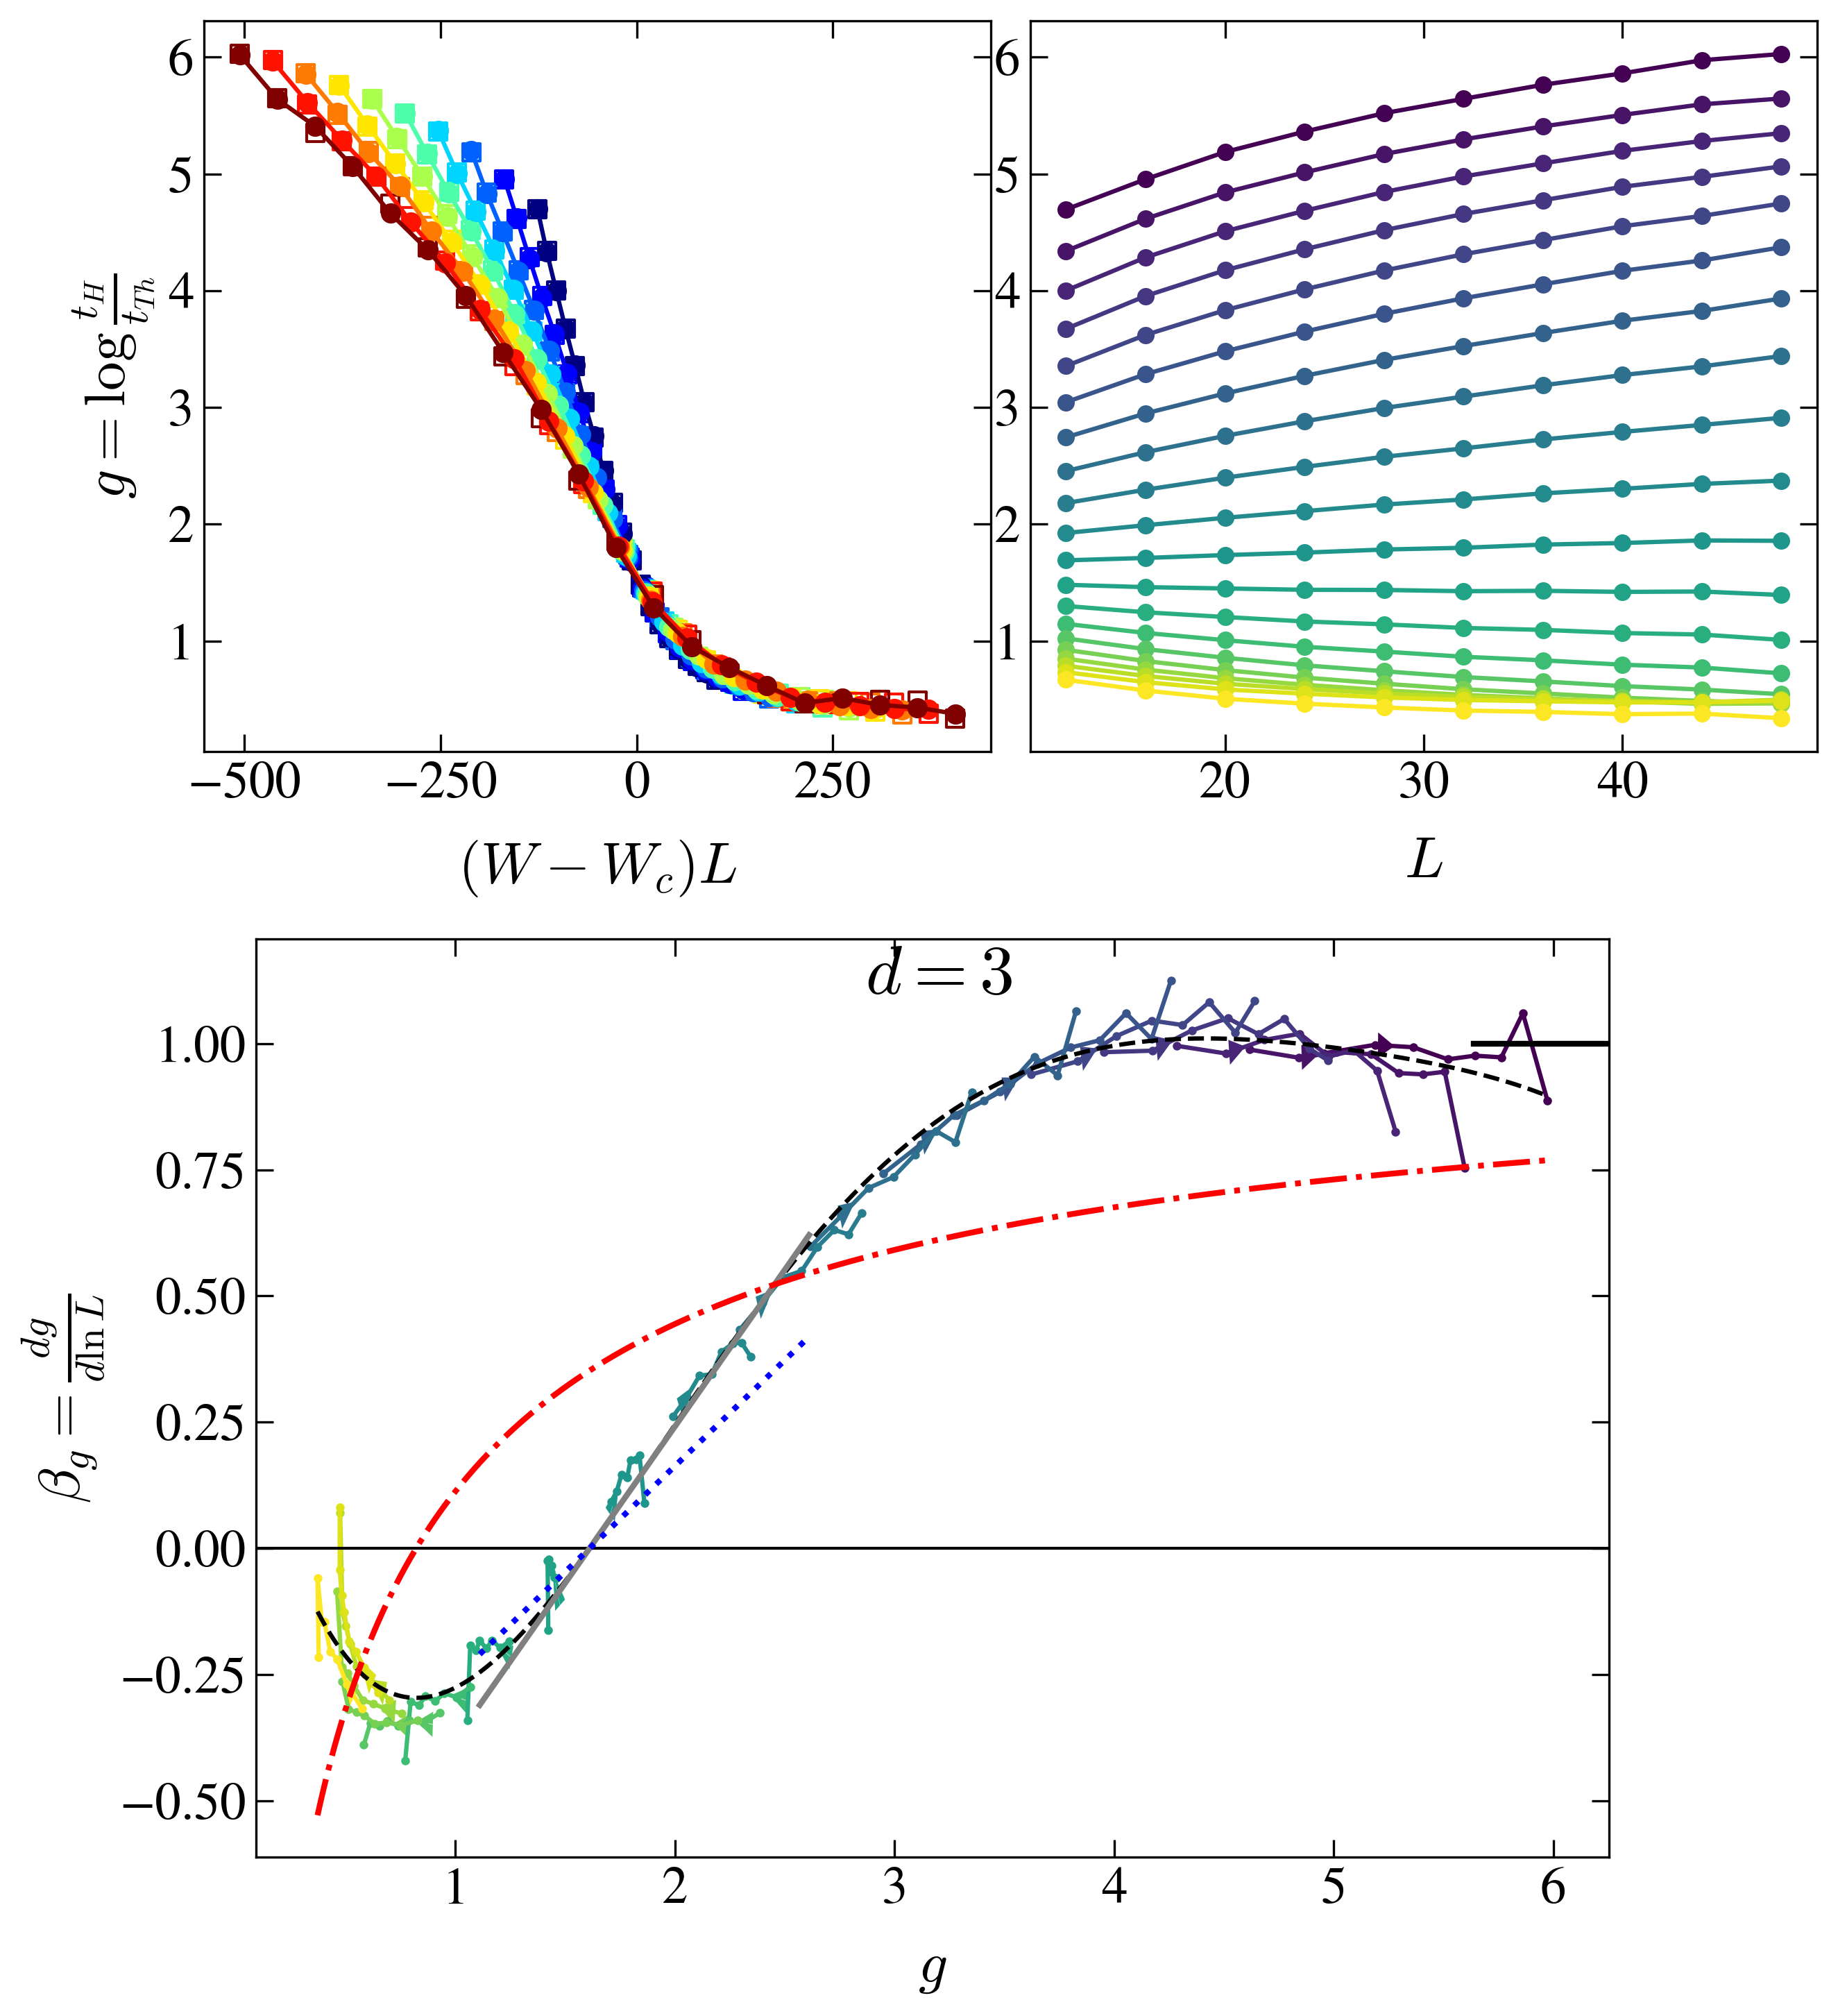

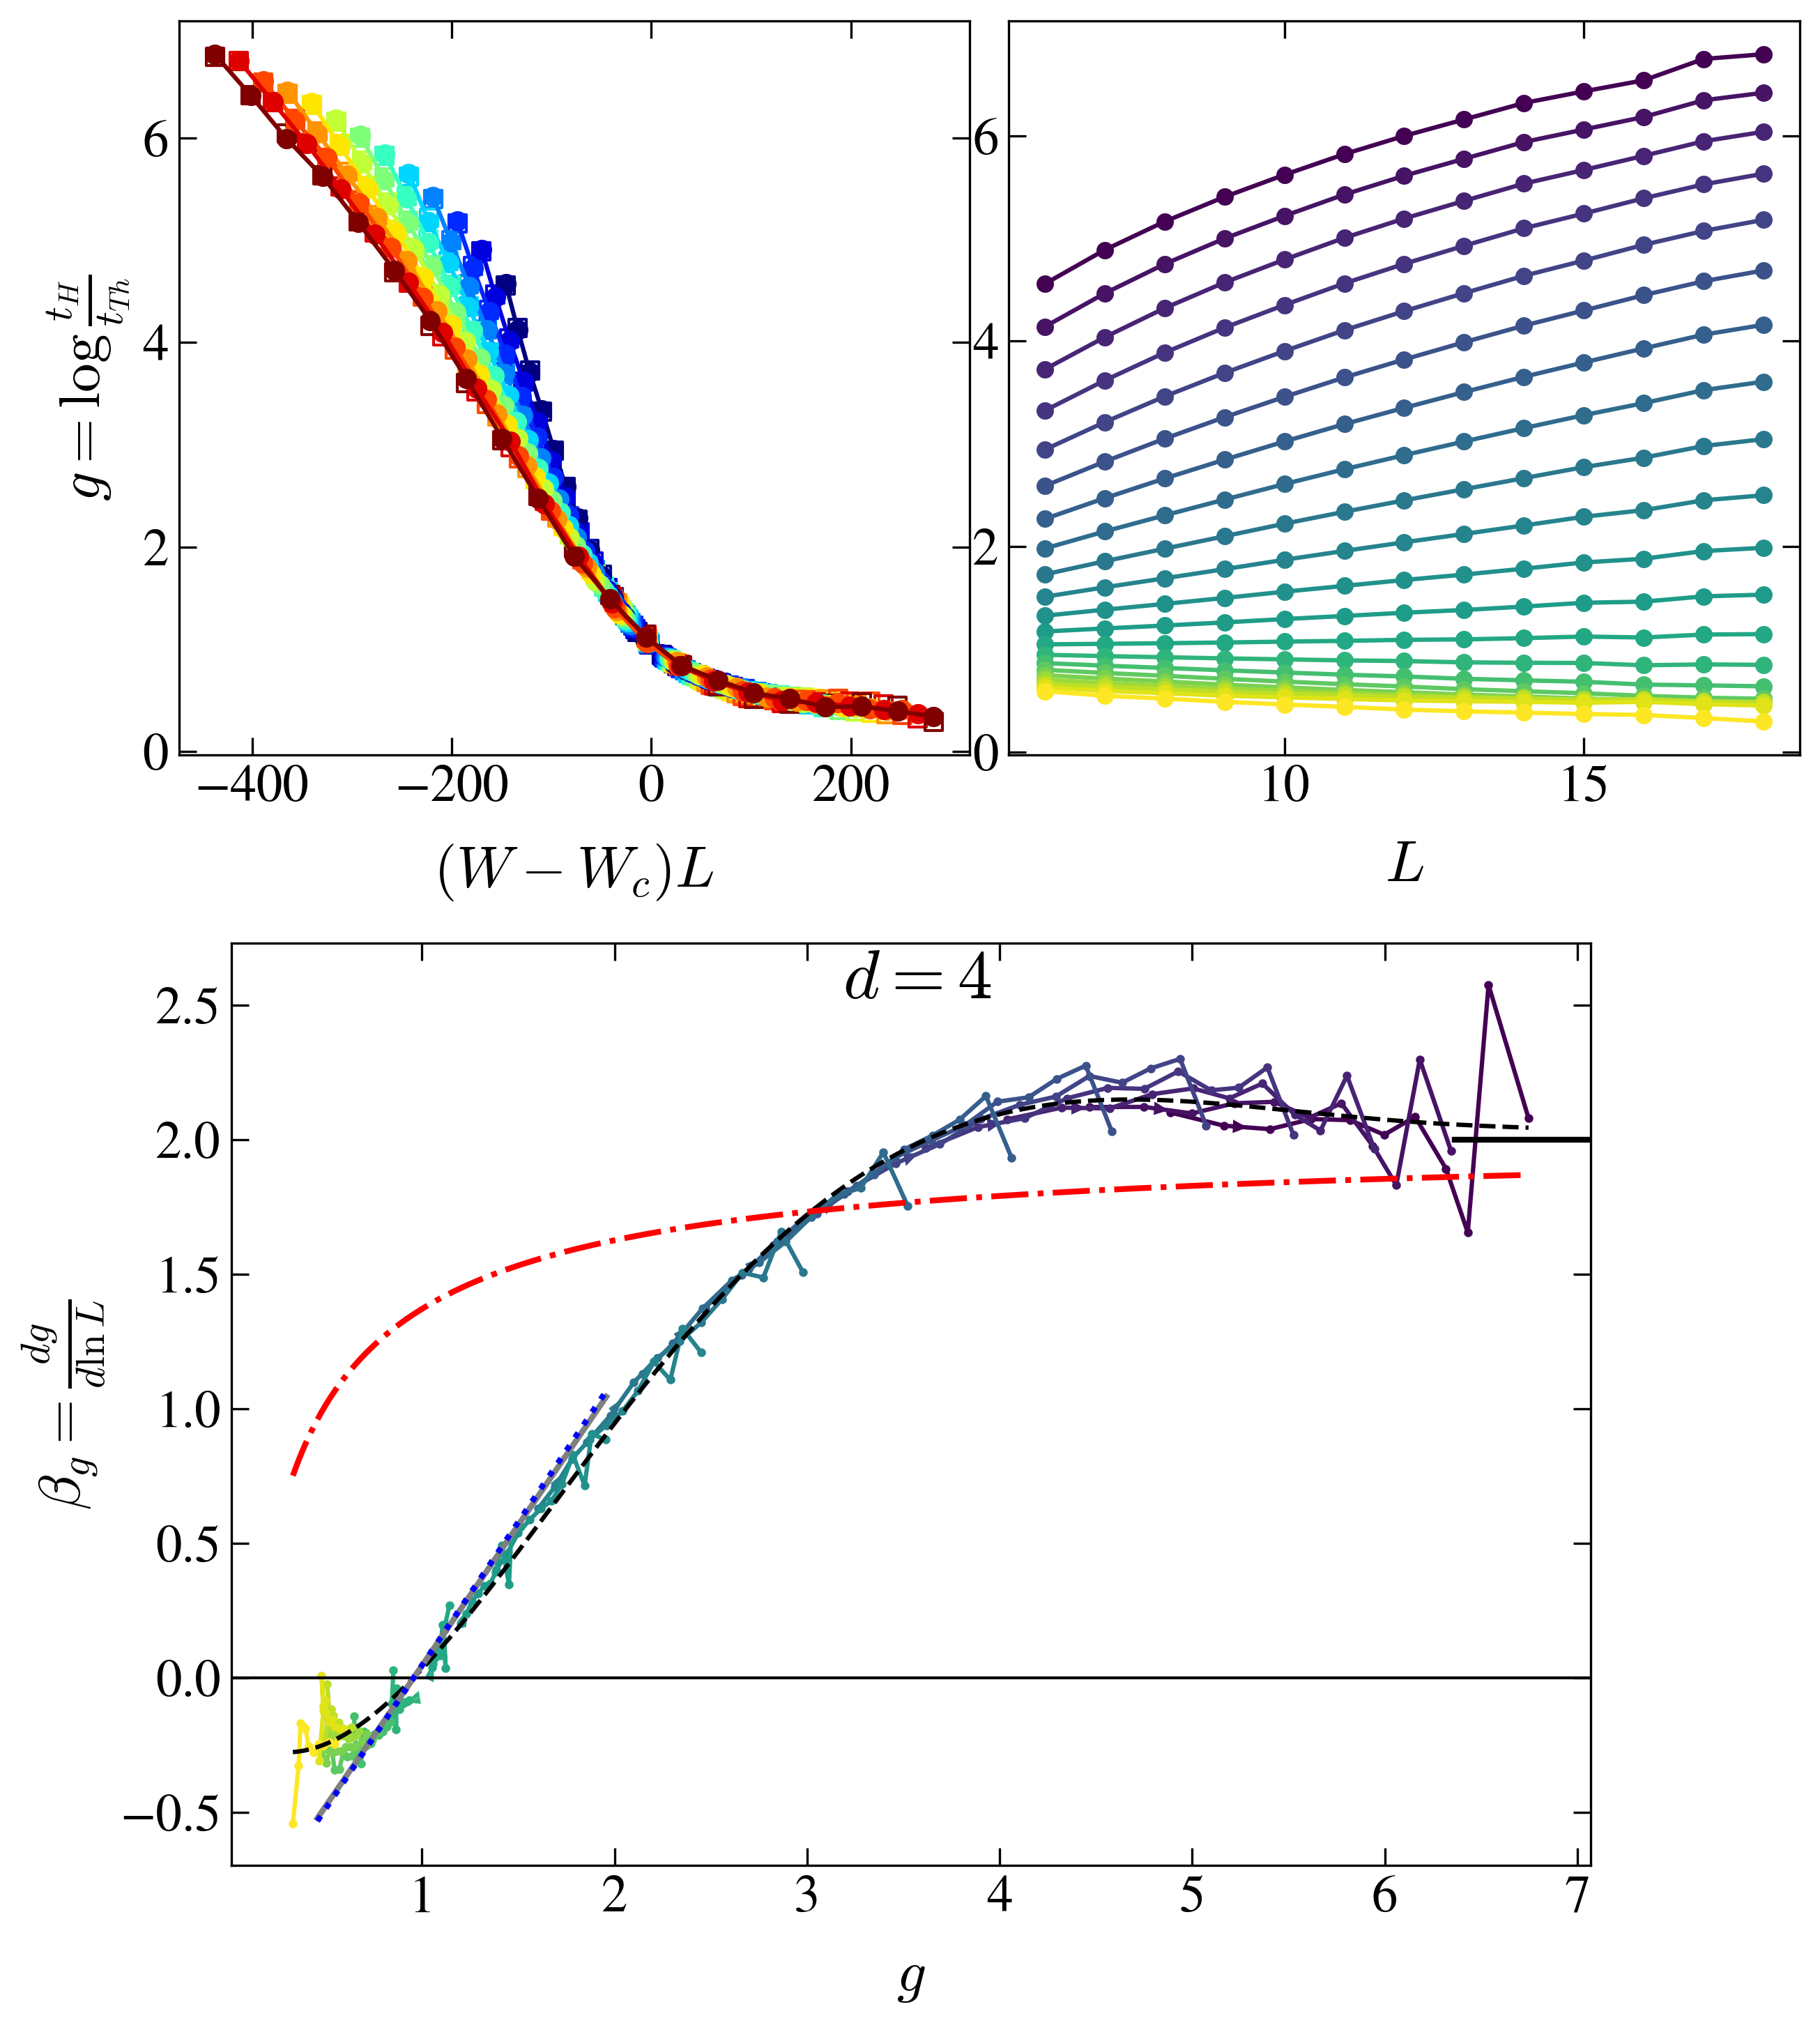

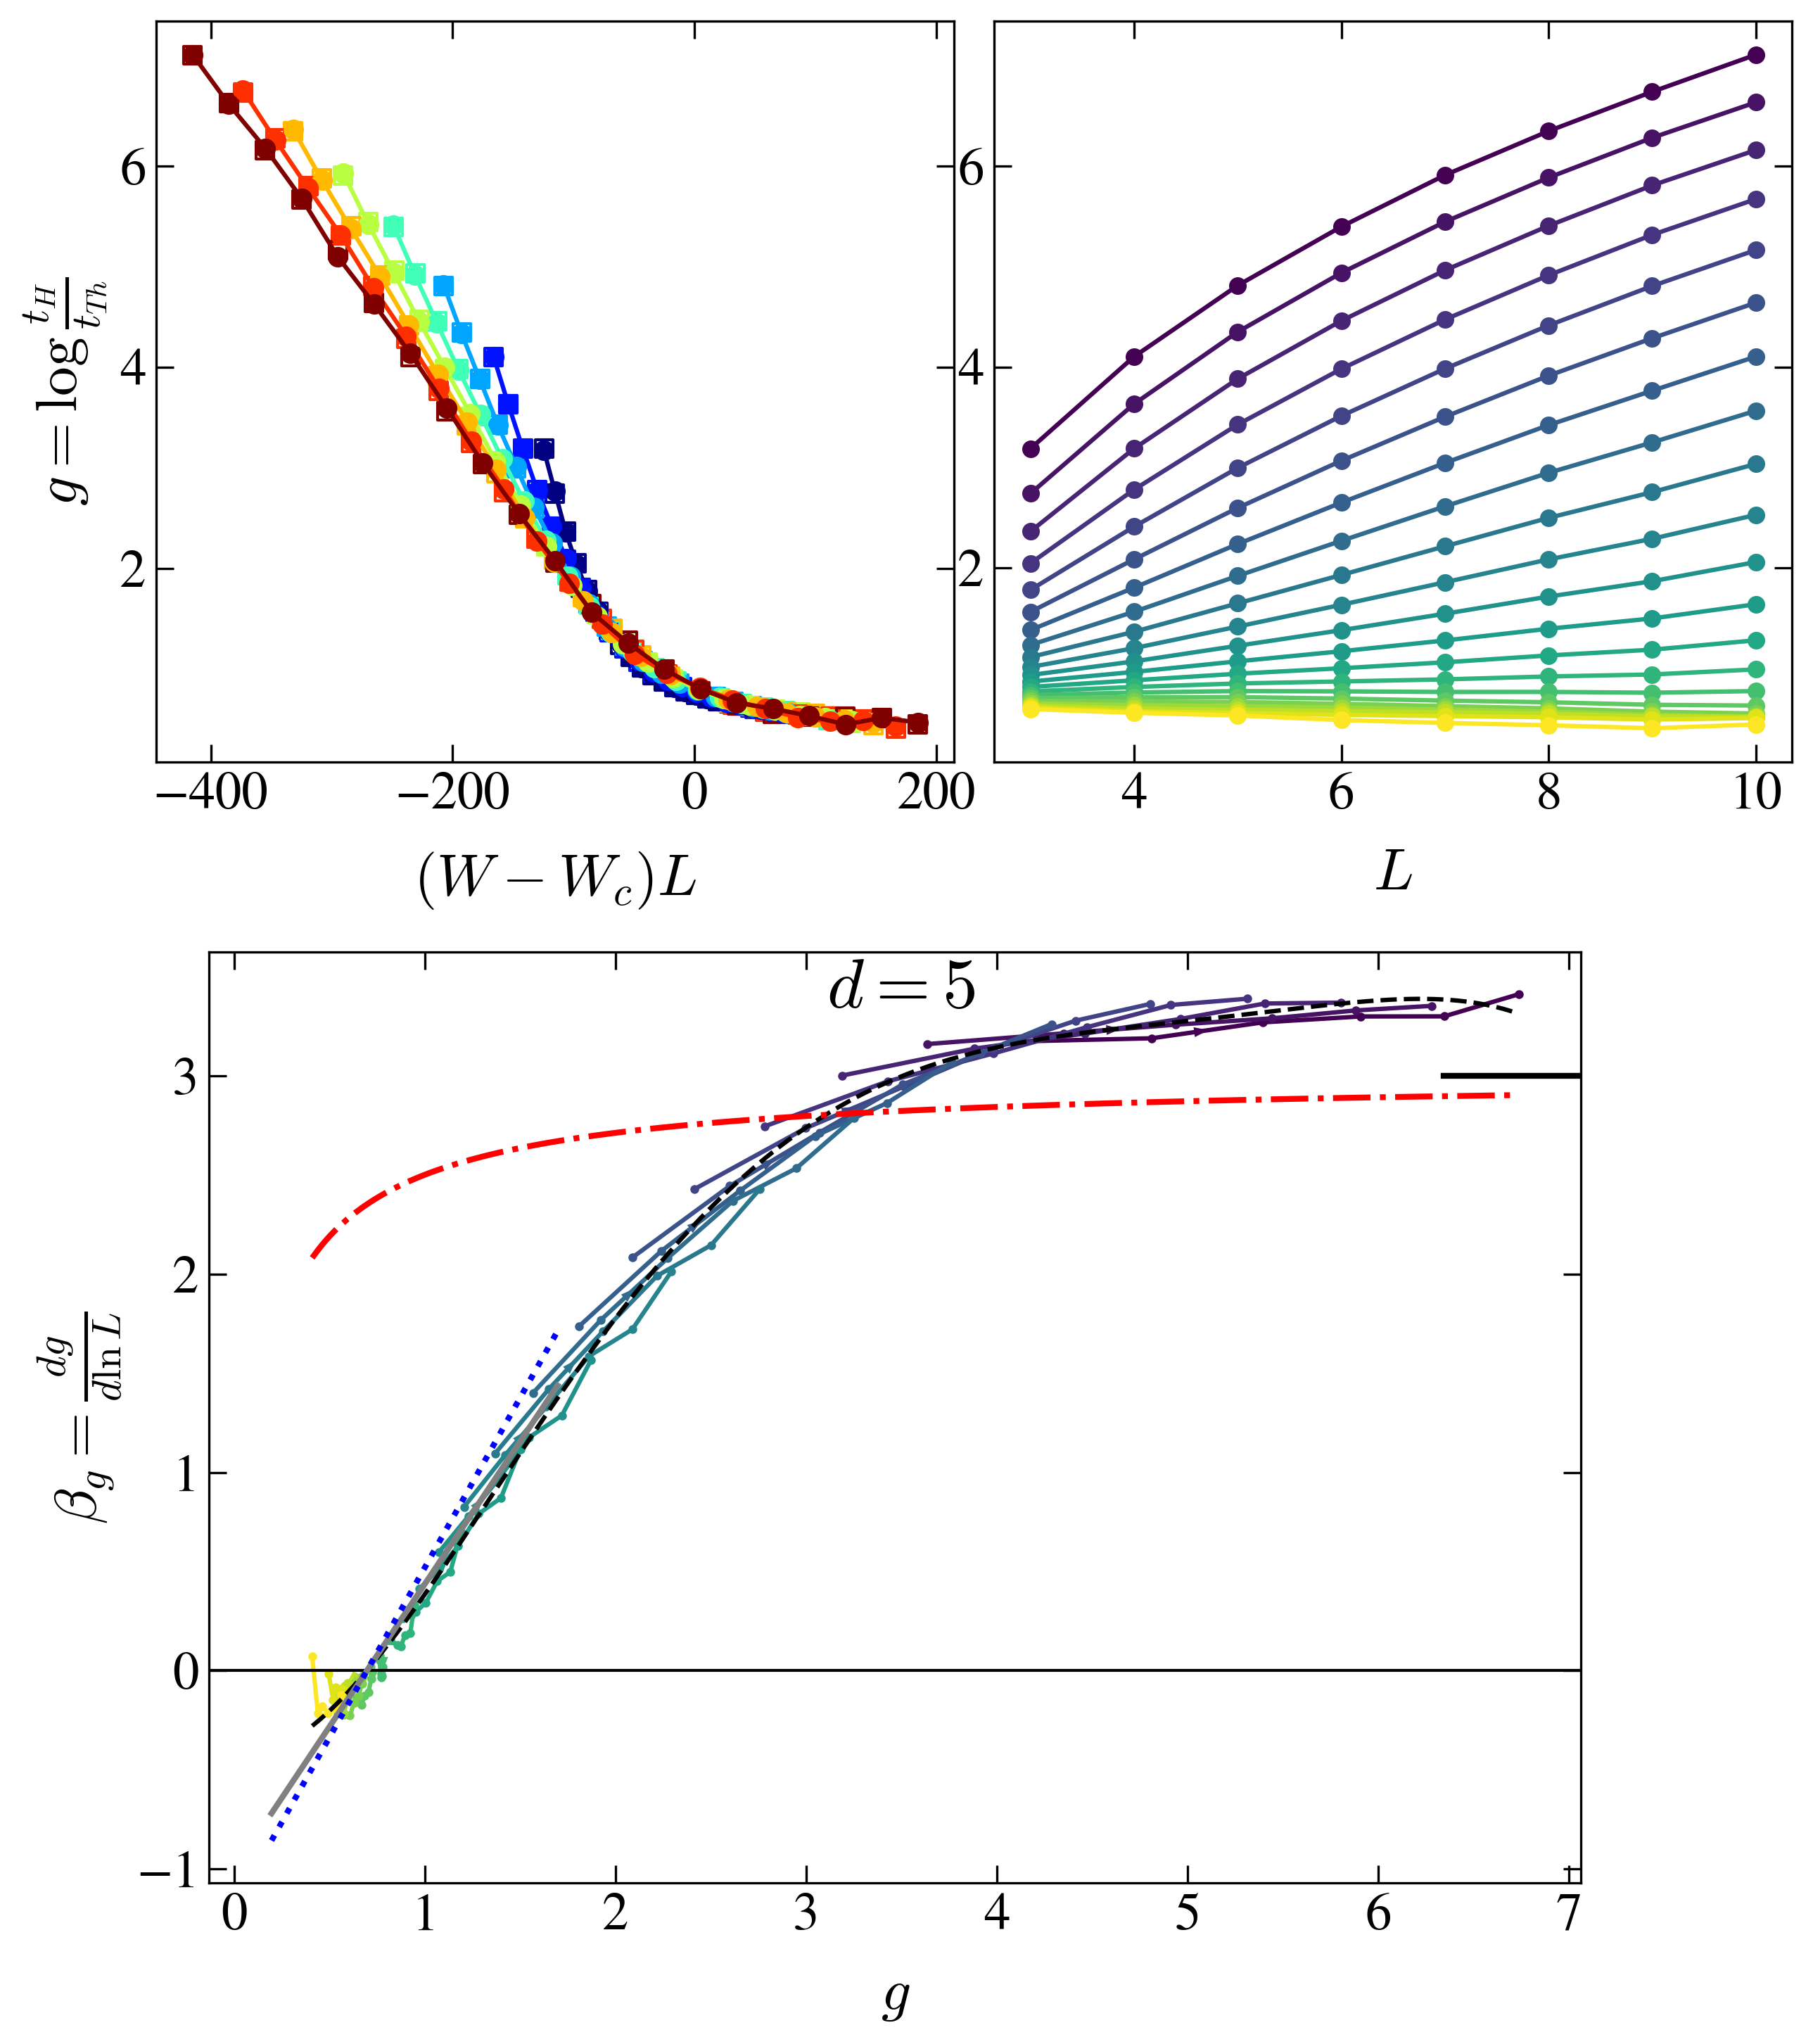

In [200]:
L = 20
w = 2
J = 1
g=0.2
op=0
modello = 'Anderson'

use_fit = 0
DIM = 3
eps = 0.5


for DIM in range(3, 6):
    

    def th_fit(L, a, b, c, d):
        # return A * g / xi
        # return (L**(DIM-1) + a * L**(DIM-2) + b) / (L**(DIM-1) + c * L**(DIM-2) + d)
        return a * L**(DIM - 2) + b * L**(DIM - 3) + c * np.log(L) + d

    def th_fit2(L, a, b):
        # return a / np.log(L) + b / L + c / (L * np.log(L)) + k
        return a * np.exp(-b*L)
        # return -g / xi + A
    prefix = base_dir(model=modello, d=DIM) + 'SpectralFormFactor/'

    folder = f'./thouless time/Anderson/d=%d/'%DIM

    if DIM == 3:    sizes = np.arange(12, 49, 4)
    elif DIM == 4:  sizes = np.arange(6, 19, 1)
    elif DIM == 5:  sizes = np.arange(3, 11, 1)


    fig = plt.figure(figsize=(10,9), dpi = 300)
    gs1 = GridSpec(1, 1)
    gs1.update(top=0.51, bottom=0.02, left=0.15, right=0.8)
    axis = fig.add_subplot(gs1[0,0])

    gs2 = GridSpec(1, 2)
    gs2.update(top=1, bottom=0.61, wspace=0.05, hspace=0.25)
    ax1 = fig.add_subplot(gs2[0])
    ax2 = fig.add_subplot(gs2[1])
    axis = [axis, ax1, ax2]

    norm = matplotlib.colors.Normalize(
            vmin=min(sizes),
            vmax=max(sizes))
    s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
    s_m.set_array([])

    r_idx = 5
    corr = 0
    Ws = [2, 6, 10, 16]

    if DIM == 3:    Ws = np.arange(1, 26, 1);   Wmin = 6; Wmax = 30; W_crit = 16.54;    nu = 1.48
    elif DIM == 4:  Ws = np.arange(2, 51, 2);   Wmin = 10; Wmax = 60; W_crit = 34.30;    nu = 0.98
    elif DIM == 5:  Ws = np.arange(3, 76, 3);   Wmin = 15; Wmax = 80; W_crit = 56.50;    nu = 0.84
    else: Ws = []

    labs = ["(a)", "(b)", "(c)", "(d)"]


    norm = matplotlib.colors.Normalize(
        vmin=np.min(sizes),
        vmax=np.max(sizes))

    # create a ScalarMappable and initialize a data structure
    s_m_L = matplotlib.cm.ScalarMappable(cmap='jet', norm=norm)
    s_m_L.set_array([])



    window = 50
    cut = 0.1
    conductivity = []
    g_crit = 0
    count = 0
    for ii, L in enumerate(sizes):
        # name_out = folder + f'_L={L}.hdf5'
        name_out = folder + f'_L=%d_eps=%.2f.hdf5'%(L, eps)
        
        if exists(name_out):
            with h5py.File(name_out, "r") as file:
                Ws  = np.array(file.get('disorder'))
                thouless  = np.array(file.get('thouless conductivity'))
                
                idx = np.argmin( np.abs(Ws - W_crit))
                g_crit += thouless[idx]
                count +=1 
                
                indices = np.where(np.logical_and(Ws >= Wmin, Ws < Wmax))[0]
                Ws = Ws[indices]
                thouless = thouless[indices]
                # Ws = Ws[~np.isnan(thouless)]
                # thouless = thouless[~np.isnan(thouless)]
                
                tH  = np.array(file.get('heisenberg time'))
                tH_typ  = np.array(file.get('typical heisenberg time'))
                gap_ratio  = np.array(file.get('gap ratio'))
                
                def rescaleW(Wx):
                    # return np.abs(Wx - W_crit)**(0.5 + (DIM-2) / DIM) * L
                    return (Wx - W_crit) * L
                
                axis[1].plot(rescaleW(Ws), thouless, marker='o', color = s_m_L.to_rgba(L))
                
                # if interpolate:
                f = splrep(Ws, thouless, k=5, s=1)
                # Ws = np.linspace(xx[0], xx[-1], xx.size + (xx.size-1) * 2)
                thouless = splev(Ws, f)
                conductivity.append(thouless)
                
                axis[1].scatter(rescaleW(Ws), thouless, marker='s', color = s_m_L.to_rgba(L), facecolor='None')
        else:
            print(name_out)
    g_crit /= count
    fig_help.set_plot_elements(axis[1], ylabel=r"$g=\log\frac{t_H}{t_{Th}}$", xlabel=r"$(W-W_c)L$", font_size=18, set_legend=False, xscale='linear', yscale='linear')
    # fig_help.set_legend(axis[1], fontsize=16, loc='upper right', anchor=(1.03, 1.03))

    conductivity = np.transpose( np.array(conductivity) )
    norm = matplotlib.colors.Normalize(
        vmin=np.min(Ws),
        vmax=np.max(Ws) )
    # create a ScalarMappable and initialize a data structure
    s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=norm)
    s_m.set_array([])


    yax_max = -10
    yax_min = 10
    envelope_xdata = []
    envelope_ydata = []
    for iiw, Wx in enumerate(Ws):
        col = s_m.to_rgba(Wx)
        # col = s_m.to_rgba(alfa)
        yy = conductivity[iiw]
        xx = sizes[~np.isnan(yy)]
        yy = yy[~np.isnan(yy)]
        
        if not use_fit:
            axis[2].plot(xx, yy, marker='o', markersize=5, color=col)
            
            beta = diff_central( np.log(xx), (yy))# * xx[1:-1] / yy[1:-1]
            xx_beta = yy[1:-1]

            line, = axis[0].plot(xx_beta, beta, marker='o', markersize=2, lw=1.5, color=col)
            
            envelope_ydata = [*envelope_ydata, *beta]
            envelope_xdata = [*envelope_xdata, *xx_beta]
            # envelope_ydata = [*envelope_ydata, (beta[-1])]
            # envelope_xdata = [*envelope_xdata, (xx_beta[-1])]
            
            if min(beta) < yax_min: yax_min = min(beta)
            if max(beta) > yax_max: yax_max = max(beta)
            
            i1 = 1
            dx = xx_beta[i1+1] - xx_beta[i1]
            dy = beta[i1+1] - beta[i1]
            pos_x = xx_beta[i1] + dx/2
            pos_y = beta[i1] + dy/2
            
            axis[0].arrow(pos_x, pos_y, 0.01 * dx, 0.01 * dy, shape='full', lw=0, length_includes_head=True, head_width=.05, color=col)
        else:
            my_fit = th_fit if Wx <= W_crit else th_fit2
            try:
                # xx = xx - N
                axis[2].scatter(xx, yy, marker='o', s=30, color=col)
                
                pars, pconv, fit_info, msg, _ = fit(my_fit,
                                xdata = xx,
                                ydata = yy,
                                full_output=True, maxfev=10000)
                # print(J, alfa, fit_info['fvec'])
                dense_sizes = np.linspace(xx[0]-1, xx[-1]+1, 10000)
                
                axis[2].plot(dense_sizes, my_fit(dense_sizes, *pars), lw=1.5, color=col, ls = '-')
            except RuntimeError:
                print(g, "Failed")
            dense_sizes = np.linspace(xx[0], xx[-1], 50)
            smooth_data = my_fit(dense_sizes, *pars)
            
            deriv = diff_central(np.log(dense_sizes), (smooth_data))
            smooth_data = smooth_data[1:-1]
            axis[0].plot(smooth_data, deriv, lw=1.5, color=col)
            
            if min(deriv) < yax_min: yax_min = min(deriv)
            if max(deriv) > yax_max: yax_max = max(deriv)
            
            envelope_ydata = [*envelope_ydata, *deriv]
            envelope_xdata = [*envelope_xdata, *smooth_data]

            i1 = smooth_data.size // 2
            dx = smooth_data[i1+1] - smooth_data[i1]
            dy = deriv[i1+1] - deriv[i1]
            pos_x = smooth_data[i1] + dx/2
            pos_y = deriv[i1] + dy/2
            axis[0].arrow(pos_x, pos_y, 0.01 * dx, 0.01 * dy, shape='full', lw=0, length_includes_head=True, head_width=.05, color=col)
        
    fig_help.set_plot_elements(axis[2], ylabel="", xlabel=r"$L$", font_size=18, set_legend=False, xscale='linear', yscale='linear')

    axis[0].axhline(y=0, ls='-', c='k', lw=1)
    axis[0].axhline(y=DIM-2, ls='-', c='black', lw=2, xmin = 0.9)
    # inset.axvline(x=0, ls='--', c='k', lw=1)

    permut = np.argsort( np.array(envelope_xdata) )
    envelope_ydata = np.array(envelope_ydata)[permut]
    envelope_xdata = np.array(envelope_xdata)[permut]

    f = splrep(envelope_xdata, envelope_ydata, k=5, s=10)
    xx = np.linspace(envelope_xdata[0], envelope_xdata[-1], 10000)
    envelope_ydata = splev(xx, f)
    axis[0].plot(xx, envelope_ydata, color='k', ls='--')

    g_crit = xx[ np.argmin( np.abs(envelope_ydata) ) ]
    gs = np.linspace(g_crit - 0.5, g_crit + 1., 1000)
    axis[0].plot(gs, (gs - g_crit) / (g_crit), ls='-', color='gray', lw=2)
    axis[0].plot(gs, (gs - g_crit) / (g_crit * nu), ls=':', color='blue', lw=2)

    axis[0].plot(xx, (DIM-1) - (1 + xx/2/g_crit)*np.log(1 + 2*g_crit/xx), color='red', ls='-.', lw=2)
    gs = np.linspace(min(envelope_xdata), max(envelope_xdata), 1000)
    # axis[0].plot(gs, (DIM-2) * (1 - g_crit / (gs)), lw=2, ls='-', color='gray', label=r"$\beta_{sp}(g_{\rm Th})$")

    # gs = np.linspace(2 * gth_crit, gmax, 1000)
    # axis[0].plot(gs, 1 + 2 / gs, lw=1, ls='-.', color='r', label=r"$\beta_{ETH}(g_{\rm Th})$")


    # axis[0].plot(np.nan, np.nan, lw=1, ls=':', color='k', label=r"$\beta(g_{\rm Th},\gamma)$")

    xlab = r"$g$"
    ylab = r"${\beta}_g=\frac{dg}{d\ln{L}}$"
    fig_help.set_plot_elements(axis[0], xlabel=xlab, ylabel=ylab, font_size=18, set_legend=False, xscale='linear')
    fig_help.set_legend(axis[0], loc = 'upper left', fontsize=14, anchor=(0.02, 0.91))
    
    axis[0].annotate(r"$d=%d$"%DIM, fontsize=24, xy=(0.45, 0.94), xycoords='axes fraction')

In [1]:
print(9**5, 10**5, 11**5, 17**4, 18**4, 19**4, 20**4, 48**3, 52**3, 56**3)
print(15**4)

# Implement kappa (openness) to make single-realisations thouless time

59049 100000 161051 83521 104976 130321 160000 110592 140608 175616
50625


# SOME MATRIX ELEMENTS

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


0.2 0.19
6 100 24 232.37900077244518 10.120704067801334
0.2 0.19
7 100 24 232.37900077244518 9.197603669579163
0.2 0.19
8 100 24 232.37900077244518 8.449162165538764
0.2 0.19
9 100 24 232.37900077244518 7.828123741190569
0.2 0.19
10 100 24 232.37900077244518 10.157669799766504
0.2 0.19
11 100 24 232.37900077244518 9.31271930064026
0.35 0.35
6 100 24 232.37900077244518 16.412333758821603
0.35 0.35
7 100 24 232.37900077244518 14.160425339727809
0.35 0.35
8 100 24 232.37900077244518 18.45306925874678
0.35 0.35
9 100 24 232.37900077244518 15.999189847164907
0.35 0.35
10 100 24 232.37900077244518 19.649538489811473
0.35 0.35
11 100 24 232.37900077244518 17.198186148442833
0.5 0.49
6 100 24 232.37900077244518 16.412333758821603
0.5 0.49
7 100 24 232.37900077244518 21.801074824001418
0.5 0.49
8 100 24 232.37900077244518 27.270688006984926
0.5 0.49
9 100 24 232.37900077244518 22.872737545349793
0.5 0.49
10 100 24 232.37900077244518 27.329487420255404
0.5 0.49
11 100 24 232.37900077244518 23.37

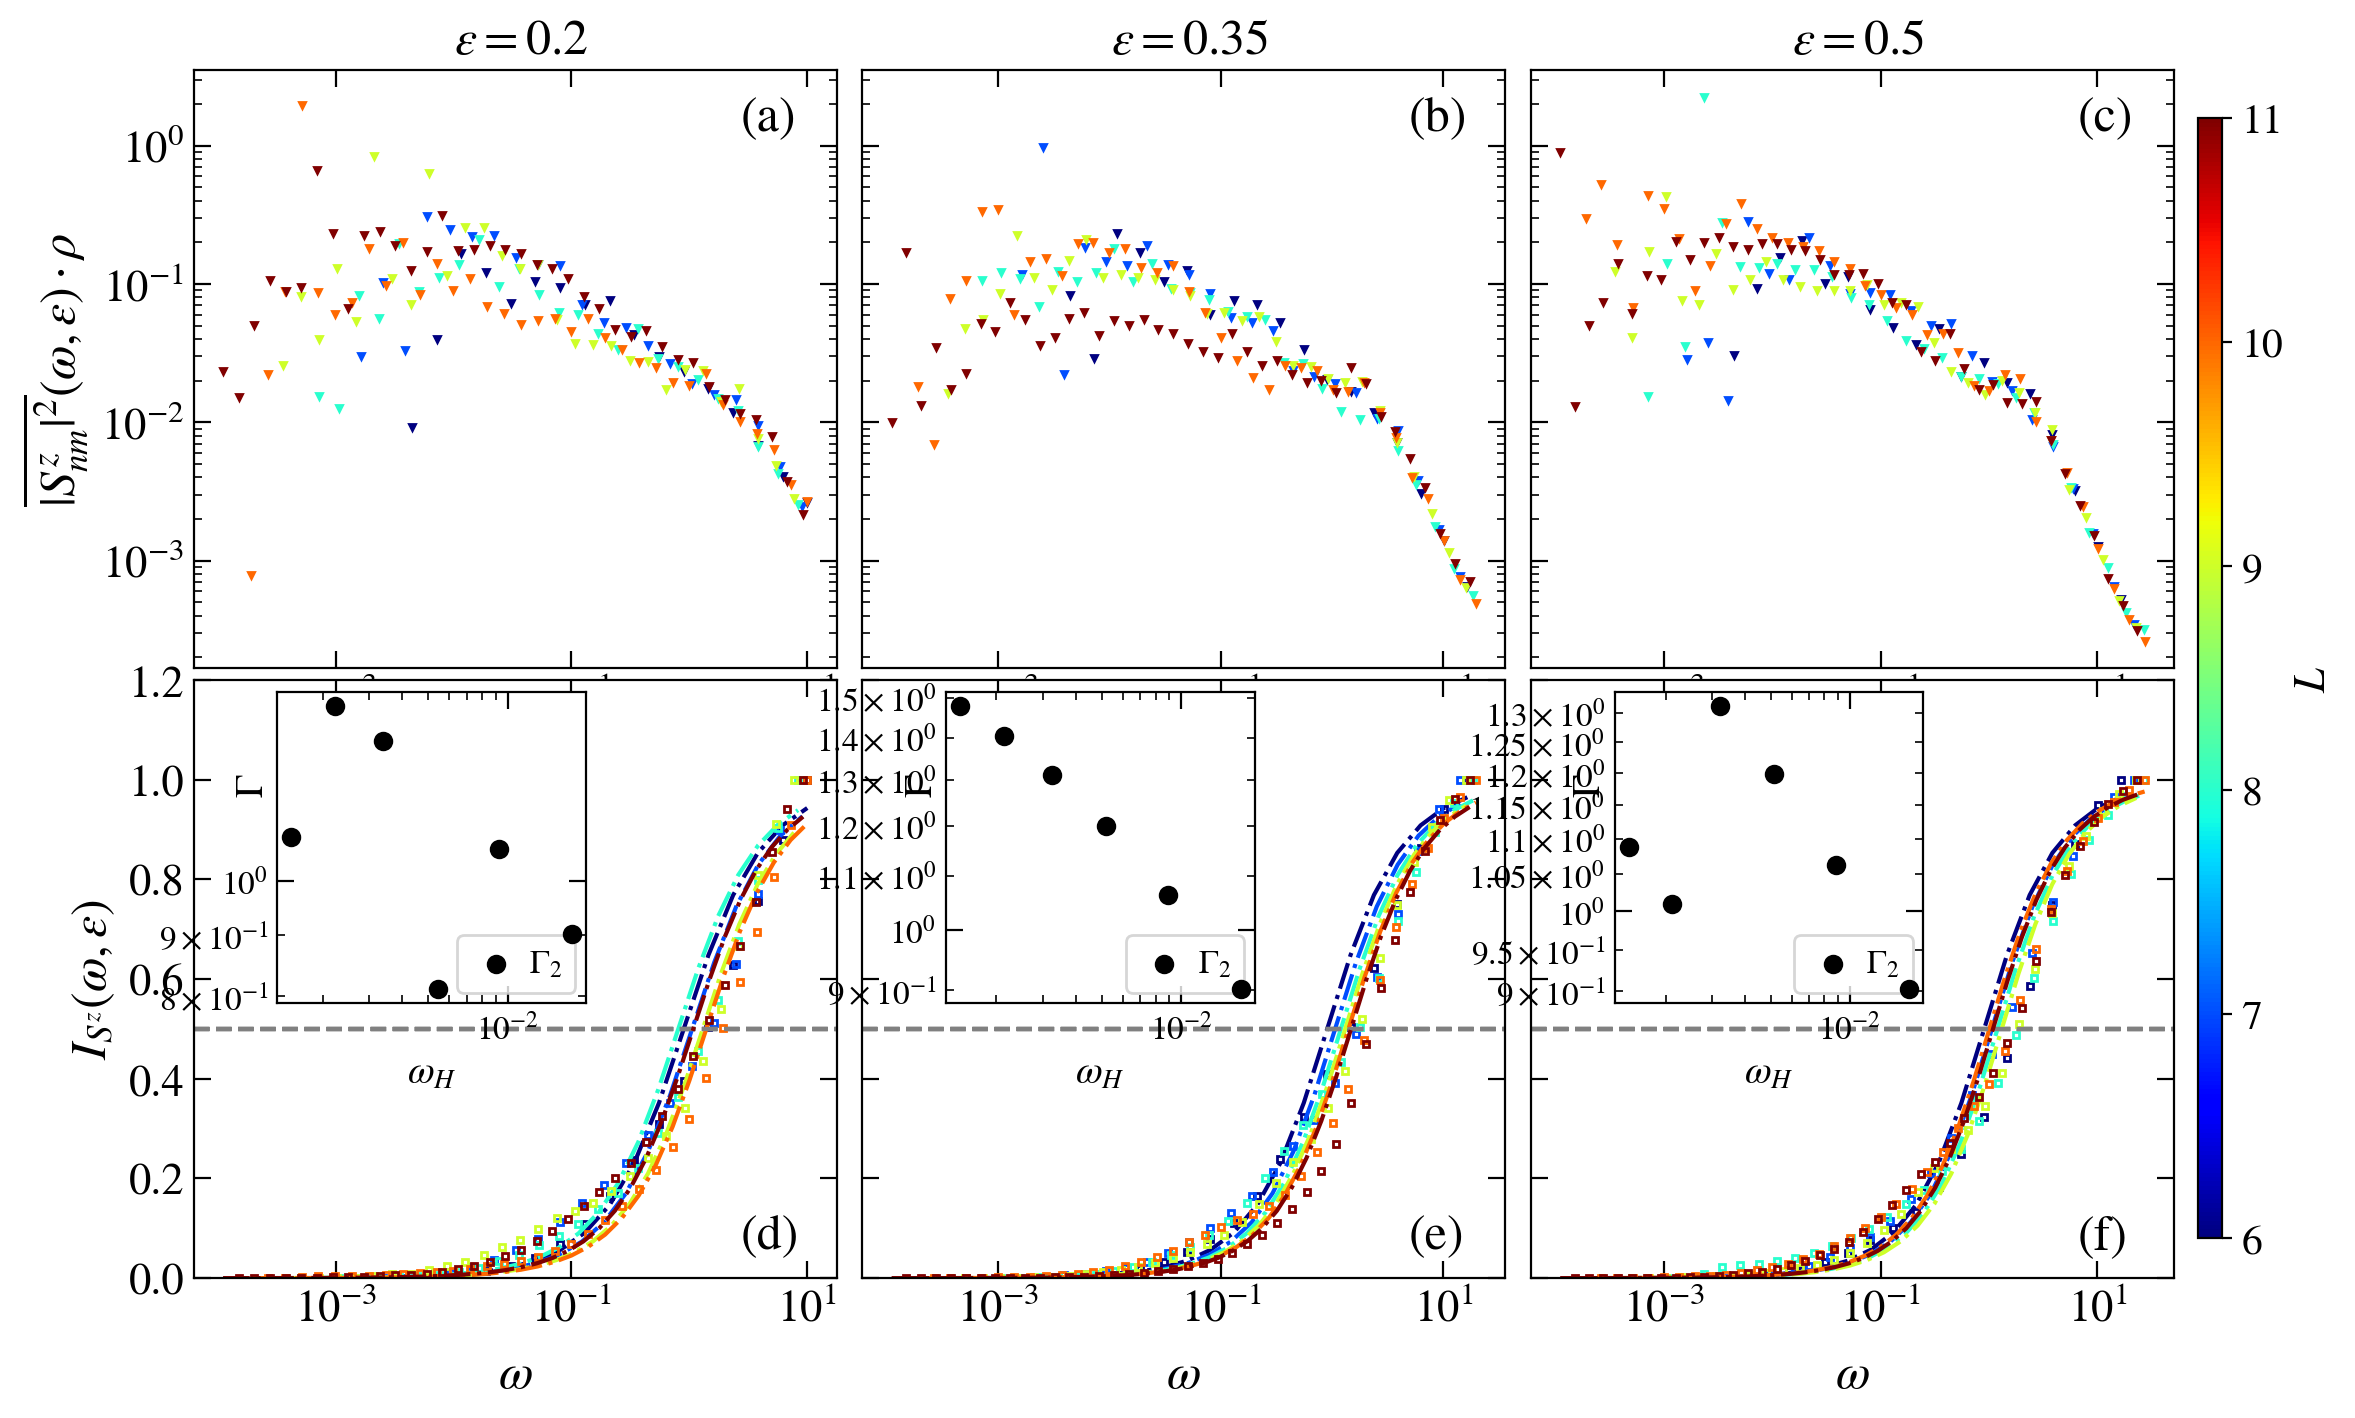

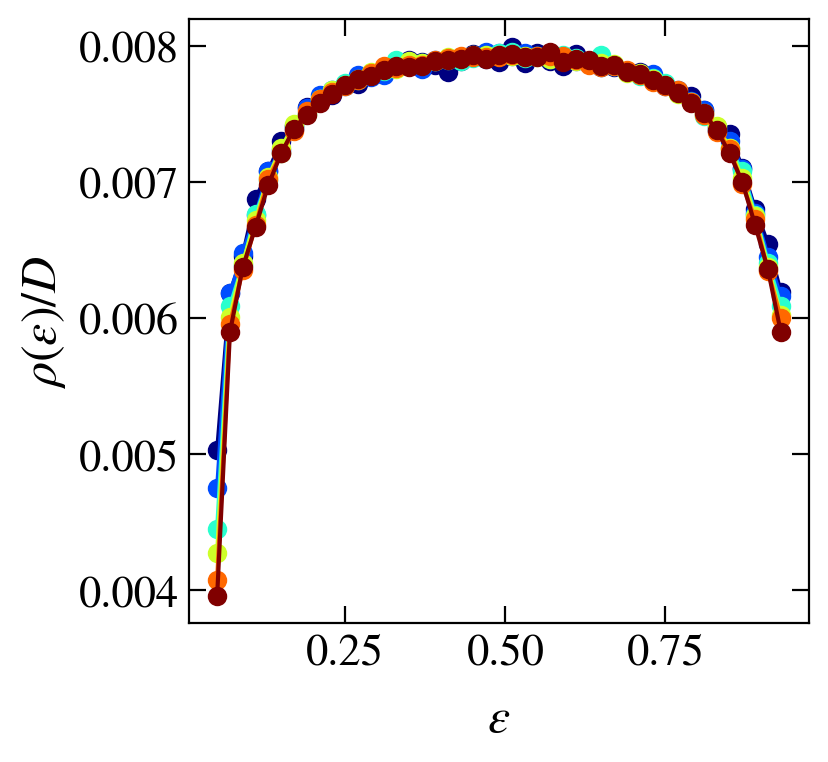

In [80]:
markers = itertools.cycle(markers_ls)
colors_ls_cyc = itertools.cycle(colors_ls)
L = 20
w = 2
J = 1
g = 2.2

DIM=4
op=0
modello = 'Anderson'
prefix = base_dir(model=modello, d=DIM) + 'OrbitalsMatElem/'

sizes = np.arange(10, 21, 2) if DIM == 3 else np.arange(6, 12, 1)

ws=100
wx=17 if DIM == 3 else 24

def lorenz(x, A, G1):
    return A / ( (x / G1)**2 + 1)

def arctan(x, G):
    return 2 / np.pi * np.arctan(x / G)

AGP = 1

# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=matplotlib.colors.Normalize(vmin=min(sizes),vmax=max(sizes) ))
s_m.set_array([])

fig, axis = plt.subplots( nrows=2, ncols=3, figsize=(12,8), dpi = 200, sharex = False, sharey = 'row')
# axis = np.array(axis).flatten()

fig2, axis2 = plt.subplots( nrows=1, ncols=1, figsize=(4,4), dpi = 200, sharex = False, sharey = 'row')

E = np.arange(0.05, 0.95, 0.02)
omegax = np.zeros( (8 * (L)) )

labs = ["(a)", "(b)", "(c)"]
labs2 = ["(d)", "(e)", "(f)"]
_eps_ = [0.2, 0.35, 0.5]
# _eps_ = [0.5, 0.65, 0.8]

upper_cut = 10
for iie, eps in enumerate(_eps_):
    # idx = min(range(len(E)), key=lambda i: abs(E[i] - eps))
    
    all_spec = []
    all_spec_typ = []
    cut = 0
    wH = np.zeros(sizes.shape)
    spec_at_wH = np.zeros(sizes.shape)
    Gammas1 = []
    Gammas2 = []
    spec_at_G1 = []
    spec_at_G2 = []
    for iiL, L in enumerate(sizes):
        col = s_m.to_rgba(L)
        dim = L**DIM
        name = prefix +  info(L=L, J=J, g=g, w=wx, model=modello, ext=',ws=%d.hdf5'%ws)
        if exists(name):
            with h5py.File(name, "r") as file:
                R = np.array(file.get('realisations'))
                
                Ex = np.array(file.get('energy_density'))
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                print(eps, Ex[idx])
                DOS = np.array(file.get('count')) / R
                # DOS = DOS / max(DOS) * dim
                if iie == 0:
                    axis2.plot(Ex, DOS / dim, marker='o', color=col)
                
                X = np.array(file.get('wH_typ_density'))[idx]
                wH[iiL] = X
                cut = X
                omegax = np.array(file.get('omegas'))
                _w_max = np.max(omegax)
                
                omegax = np.sqrt(omegax[1:] * omegax[:-1])[20:]
                
                spec_fun = np.array(file.get('spec_fun'))[idx,20:] * DOS[idx]
                spec_fun_typ = np.array(file.get('spec_fun_typ'))[idx,20:] * DOS[idx]
                elem_count = np.array(file.get('element_count'))[idx,20:]
                
                num_av = 3
                end_idx = int(spec_fun.size / float(num_av)) * num_av
                x = np.zeros( (spec_fun[:end_idx:num_av].size) )
                y = np.zeros( (spec_fun[:end_idx:num_av].size) )
                z = np.zeros( (spec_fun[:end_idx:num_av].size) )
                w = np.zeros( (spec_fun[:end_idx:num_av].size) )
                for ijk in range(num_av):
                    x += spec_fun[ijk:end_idx:num_av] * elem_count[ijk:end_idx:num_av]
                    y += spec_fun_typ[ijk:end_idx:num_av] * elem_count[ijk:end_idx:num_av]
                    z += elem_count[ijk:end_idx:num_av]
                    w += omegax[ijk:end_idx:num_av]
                spec_fun = x / z
                spec_fun_typ = y / z
                elem_count = z / num_av
                omegax = w / num_av
                sig = 0.5
                a=1
                
                wH_idx = min(range(len(omegax)), key=lambda i: abs(omegax[i] - wH[iiL]))
                spec_at_wH[iiL] = spec_fun[wH_idx]
                
                all_spec.append(spec_fun)
                all_spec_typ.append(spec_fun_typ)
                
                R = np.array(file.get('realisations'))
        else:
            print(name)

        yy0 = spec_fun if AGP else spec_fun_typ
        
        
        omegax = omegax[~np.isnan(yy0)]
        yy0 = yy0[~np.isnan(yy0)]
        print(L, ws, wx, _w_max, np.max(omegax))
        
        axis[0][iie].plot(omegax, yy0, color=col, marker='v', markersize=2, lw=0,zorder=0)
        # axis[0][iie].axvline(x=upper_cut, ls=':', color='gray')
        # indices = np.where(np.logical_and(omegax >= cut, omegax < upper_cut))[0]
        # xx = omegax[indices]
        # yy = yy0[indices]
        # pars, pconv= fit(lorenz,
        #             xdata = xx,
        #             ydata = yy,
        #             maxfev = 20000)
        # z = np.linspace(min(xx), max(xx), 5000)
        # # print(eps, L, G1)
        # G1 = np.abs(pars[-1])
        # Gammas1.append(G1)
        # spec_at_G1.append(yy0[np.argmin( np.abs(omegax - G1) )])
        # axis[0][iie].plot(z, lorenz(z, *pars), ls='--', color=col)
        
        # yy = integrate.cumulative_trapezoid(yy0, omegax)
        # yy = (yy - yy[0]) / (yy[-1] - yy[0])
        
        indices = np.where(np.logical_and(omegax >= X, omegax < 100 * X))[0]
        
        xx = omegax#[indices]
        yy0 = yy0#[indices]
        yy = integrate.cumulative_trapezoid(yy0, xx)
        yy = (yy - yy[0]) / (yy[-1] - yy[0])
        
        axis[1][iie].plot(xx[1:], yy, color=col, marker='s', markersize=2, lw=0, markerfacecolor='None')
        axis[1][iie].axhline(y=0.5, ls='--', color='gray')
        
        G2 = xx[np.argmin( np.abs(yy - 0.5) )]
        spec_at_G2.append(yy0[np.argmin( np.abs(omegax - G2) )])
        Gammas2.append(G2)
        axis[1][iie].plot(xx, arctan(xx, G2), ls='-.', color=col)
        if iie == 2 and L == 12:
            axis[0][iie].plot(np.nan, np.nan, ls='--', color='k', label=r"$\frac{A}{\Gamma}\frac{1}{1+(\omega/\gamma)^2}$")
            axis[1][iie].plot(np.nan, np.nan, ls='-.', color='k', label=r"$\frac{2}{\pi}\arctan{\frac{\omega}{\Gamma}}$")
    Gammas1 = np.array(Gammas1)
    Gammas2 = np.array(Gammas2)
    # axis[0][iie].scatter(Gammas1, spec_at_G1, marker='s', color='black', label=r"$\Gamma_1$", zorder=10, facecolor='None')
    # axis[0][iie].scatter(Gammas2, spec_at_G2, marker='o', color='black', label=r"$\Gamma_2$", zorder=10)
    # axis[iie].plot(wH, spec_at_wH, marker='s', color='k', ls='--')
    if AGP : #\cdot\rho(\epsilon)
        fig_help.set_plot_elements(axis[0][iie], ylabel=r"$\overline{|S^z_{nm}|^2}(\omega,\epsilon)\cdot\rho$" if iie == 0 else "", xlabel="", font_size=16, set_legend=False, xscale='log', yscale='log')
        fig_help.set_plot_elements(axis[1][iie], ylabel=r"$I_{S^z}(\omega,\epsilon)$" if iie == 0 else "", xlabel=r"$\omega$", font_size=16, set_legend=False, xscale='log', yscale='linear')
    else:    
        fig_help.set_plot_elements(axis[0][iie], ylabel=r"$\overline{|S^z_{nm}|^2}^{\rm typ}(\omega,\epsilon)\cdot\rho$" if iie == 0 else "", xlabel="", font_size=16, set_legend=False, xscale='log', yscale='log')
        fig_help.set_plot_elements(axis[1][iie], ylabel=r"$I_{S^z}(\omega,\epsilon)$" if iie == 0 else "", xlabel=r"$\omega$", font_size=16, set_legend=False, xscale='log', yscale='linear')
    fig_help.set_legend(axis[0][iie], fontsize=16, loc='lower left')
    fig_help.set_legend(axis[1][iie], fontsize=16, loc='lower left', anchor=(-0.02, 0.05))
    axis[0][iie].set_title(r" $\epsilon=%g$"%eps, fontsize=18)
    axis[0][iie].annotate(labs[iie],     fontsize=18, xy=(0.85, 0.9), xycoords='axes fraction')
    axis[1][iie].annotate(labs2[iie],     fontsize=18, xy=(0.85, 0.05), xycoords='axes fraction')
    # axis[0][iie].set_ylim(2e-4, None)
    axis[1][iie].set_ylim(0, 1.2)
    # axis[0][iie].set_xlim(0.2*min(omegax), max(omegax))
    
    inset = axis[1][iie].inset_axes([0.13, 0.46, 0.48, 0.52])
    
        
    # inset.xaxis.set_label_coords(.45, -0.05)
    inset.yaxis.set_label_coords(-0.02, 0.7)
    # inset.scatter(wH, Gammas1, marker='s', color='black', label=r"$\Gamma_1$", zorder=10, facecolor='None')
    inset.scatter(wH, Gammas2, marker='o', color='black', label=r"$\Gamma_2$", zorder=10)
    fig_help.set_plot_elements(inset, ylabel=r"$\Gamma$", xlabel=r"$\omega_H$", font_size=12, set_legend=False, xscale='log', yscale='log')
    fig_help.set_legend(inset, fontsize=12, loc='lower right', frameon=True)
    # inset.set_yticks([0.02, 0.03, 0.04, 0.06, 0.08])
    # inset.set_yticklabels(["0.02", "0.03", "0.04", "", "0.08"])

fig_help.set_plot_elements(axis2, ylabel=r"$\rho(\epsilon)/D$", xlabel=r"$\epsilon$", font_size=16, set_legend=False, xscale='linear', yscale='linear')
  
fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.15, 0.01, 0.7])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1)
cbar.set_label(r"$L$", fontsize=16)
cbar.ax.tick_params(labelsize=15)

fig.subplots_adjust(wspace = 0.04, hspace=0.02)
# fig.savefig("plots_AGP/FigS4.pdf", bbox_inches = 'tight', pad_inches=0.02)

0.5 0.49
10 35 28 267.08300832013504 18.678576394085567
0.5 0.49
10 60 28 267.08300832013504 18.678576394085567
0.5 0.49
10 100 28 267.08300832013504 18.678576394085567


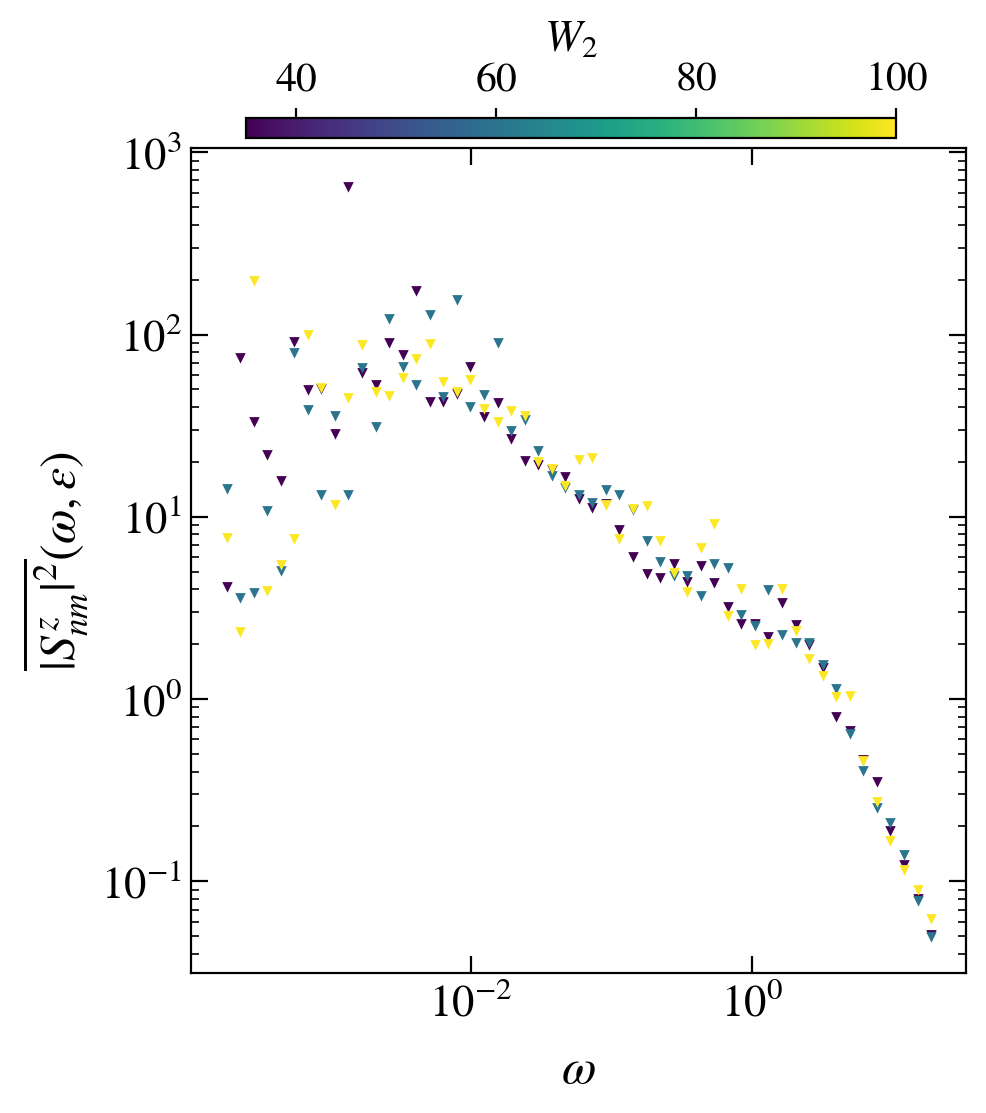

In [86]:
markers = itertools.cycle(markers_ls)
colors_ls_cyc = itertools.cycle(colors_ls)


L = 10
w = 12
J = 1
g = 1

DIM=4
op=0
modello = 'Anderson'
prefix = base_dir(model=modello, d=DIM) + 'OrbitalsMatElem/'

sizes = np.arange(10, 25, 2) if DIM == 3 else np.arange(6, 12, 1)

def lorenz(x, A, G1):
    return A / ( (x / G1)**2 + 1)

def arctan(x, G):
    return 2 / np.pi * np.arctan(x / G)

AGP = 1
INTEGRATED = 0

E = np.arange(0.05, 0.95, 0.02)
omegax = np.zeros( (10 * (L)) )

labs = ["(a)", "(b)", "(c)", "(d)"]
w_list = np.arange(10, 18, 1)
upper_cut = 100
ws = 100
wx=10 if DIM == 3 else 28
ws_list = [18, 30, 100] if DIM == 3 else [35, 60, 100]

# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='viridis', norm=matplotlib.colors.Normalize(vmin=min(ws_list),vmax=max(ws_list) ))
s_m.set_array([])

fig, axes = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200, sharex = True)
axis = [axes]

iie = 0
eps = 0.5

for ws in ws_list:
    cut = 0
    
    col = s_m.to_rgba(ws)
    dim = L**DIM
    name = prefix +  info(L=L, J=J, g=g, w=wx, model=modello, ext=',ws=%d.hdf5'%ws)
    if exists(name):
        with h5py.File(name, "r") as file:
            R = np.array(file.get('realisations'))
            
            Ex = np.array(file.get('energy_density'))
            idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
            print(eps, Ex[idx])
            DOS = np.array(file.get('DOS'))[idx]
            
            X = np.array(file.get('wH_density'))[idx]
            cut = X
            # DOS = 1/X
            omegax = np.array(file.get('omegas'))
            _w_max = np.max(omegax)
            
            omegax = np.sqrt(omegax[1:] * omegax[:-1])[20:]
            
            spec_fun = np.array(file.get('spec_fun'))[idx,20:] * DOS
            spec_fun_typ = np.array(file.get('spec_fun_typ'))[idx,20:] * DOS
            elem_count = np.array(file.get('element_count'))[idx,20:]
            
            num_av = 2
            end_idx = int(spec_fun.size / float(num_av)) * num_av
            x = np.zeros( (spec_fun[:end_idx:num_av].size) )
            y = np.zeros( (spec_fun[:end_idx:num_av].size) )
            z = np.zeros( (spec_fun[:end_idx:num_av].size) )
            w = np.zeros( (spec_fun[:end_idx:num_av].size) )
            for ijk in range(num_av):
                x += spec_fun[ijk:end_idx:num_av] * elem_count[ijk:end_idx:num_av]
                y += spec_fun_typ[ijk:end_idx:num_av] * elem_count[ijk:end_idx:num_av]
                z += elem_count[ijk:end_idx:num_av]
                w += omegax[ijk:end_idx:num_av]
            spec_fun = x / z
            spec_fun_typ = y / z
            elem_count = z / num_av
            omegax = w / num_av
                    
            yy0 = spec_fun if AGP else spec_fun_typ
            
            
            omegax = omegax[~np.isnan(yy0)][:-2]
            # count = count[~np.isnan(yy0)][:-2]
            yy0 = yy0[~np.isnan(yy0)][:-2]
            
            print(L, ws, wx, _w_max, np.max(omegax))
            if INTEGRATED:
                xx = omegax
                yy = integrate.cumulative_trapezoid(yy0, xx)
                yy = (yy - yy[0]) / (yy[-1] - yy[0])
                xx = xx[1:]
            else:
                xx = omegax
                yy = yy0 # * xx**2
            axis[iie].plot(xx, yy, color=col, marker='v', markersize=2, lw=0,zorder=0)
            # print(L, ws, np.sum(yy * count) / np.sum(count))
            # axis[0][iie].axvline(x=upper_cut, ls=':', color='gray')
            if not INTEGRATED: 
                z = np.logspace( -6, 1, 5000)
                
                # indices = np.where(np.logical_and(omegax >= cut, omegax < upper_cut))[0]
                # xx = omegax[indices]
                # yy = yy0[indices]
                # pars, pconv= fit(lorenz,
                #             xdata = xx,
                #             ydata = yy,
                #             maxfev = 20000)
                # axis[iie].plot(z, lorenz(z, *pars), ls='--', color=col)
                
                xx = omegax
                yy = integrate.cumulative_trapezoid(yy0, xx)
                yy = (yy - yy[0]) / (yy[-1] - yy[0])
                idxG = np.argmin( np.abs(yy - 0.5) )
                G = xx[1:][idxG]
                A = yy0[ np.argmin( np.abs(omegax - X)) ]
                # axis[iie].plot(z, lorenz(z, A, G), ls='--', color=col)
                
    else:
        print(name)

ylab = r"$\overline{|S^z_{nm}|^2}(\omega,\epsilon)$" if AGP else r"$\overline{|S^z_{nm}|^2}^{\rm typ}(\omega,\epsilon)$"
fig_help.set_plot_elements(axis[iie], ylabel=ylab, xlabel=r"$\omega$", font_size=16, set_legend=False, xscale='log', yscale='linear' if INTEGRATED else 'log')


    

fig.subplots_adjust(top=0.95)
cbar_ax = fig.add_axes([0.18, 0.96, 0.65, 0.02])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation='horizontal')
cbar.set_label(r"$W_2$", fontsize=16)
cbar.ax.tick_params(labelsize=15)
cbar_ax.xaxis.set_ticks_position('top')
cbar_ax.xaxis.set_label_position('top')

fig.subplots_adjust(wspace = 0.35, hspace=0.04)
# fig.savefig("PLOTS_FADING/Fig_spectral.pdf", bbox_inches = 'tight', pad_inches=0.02)

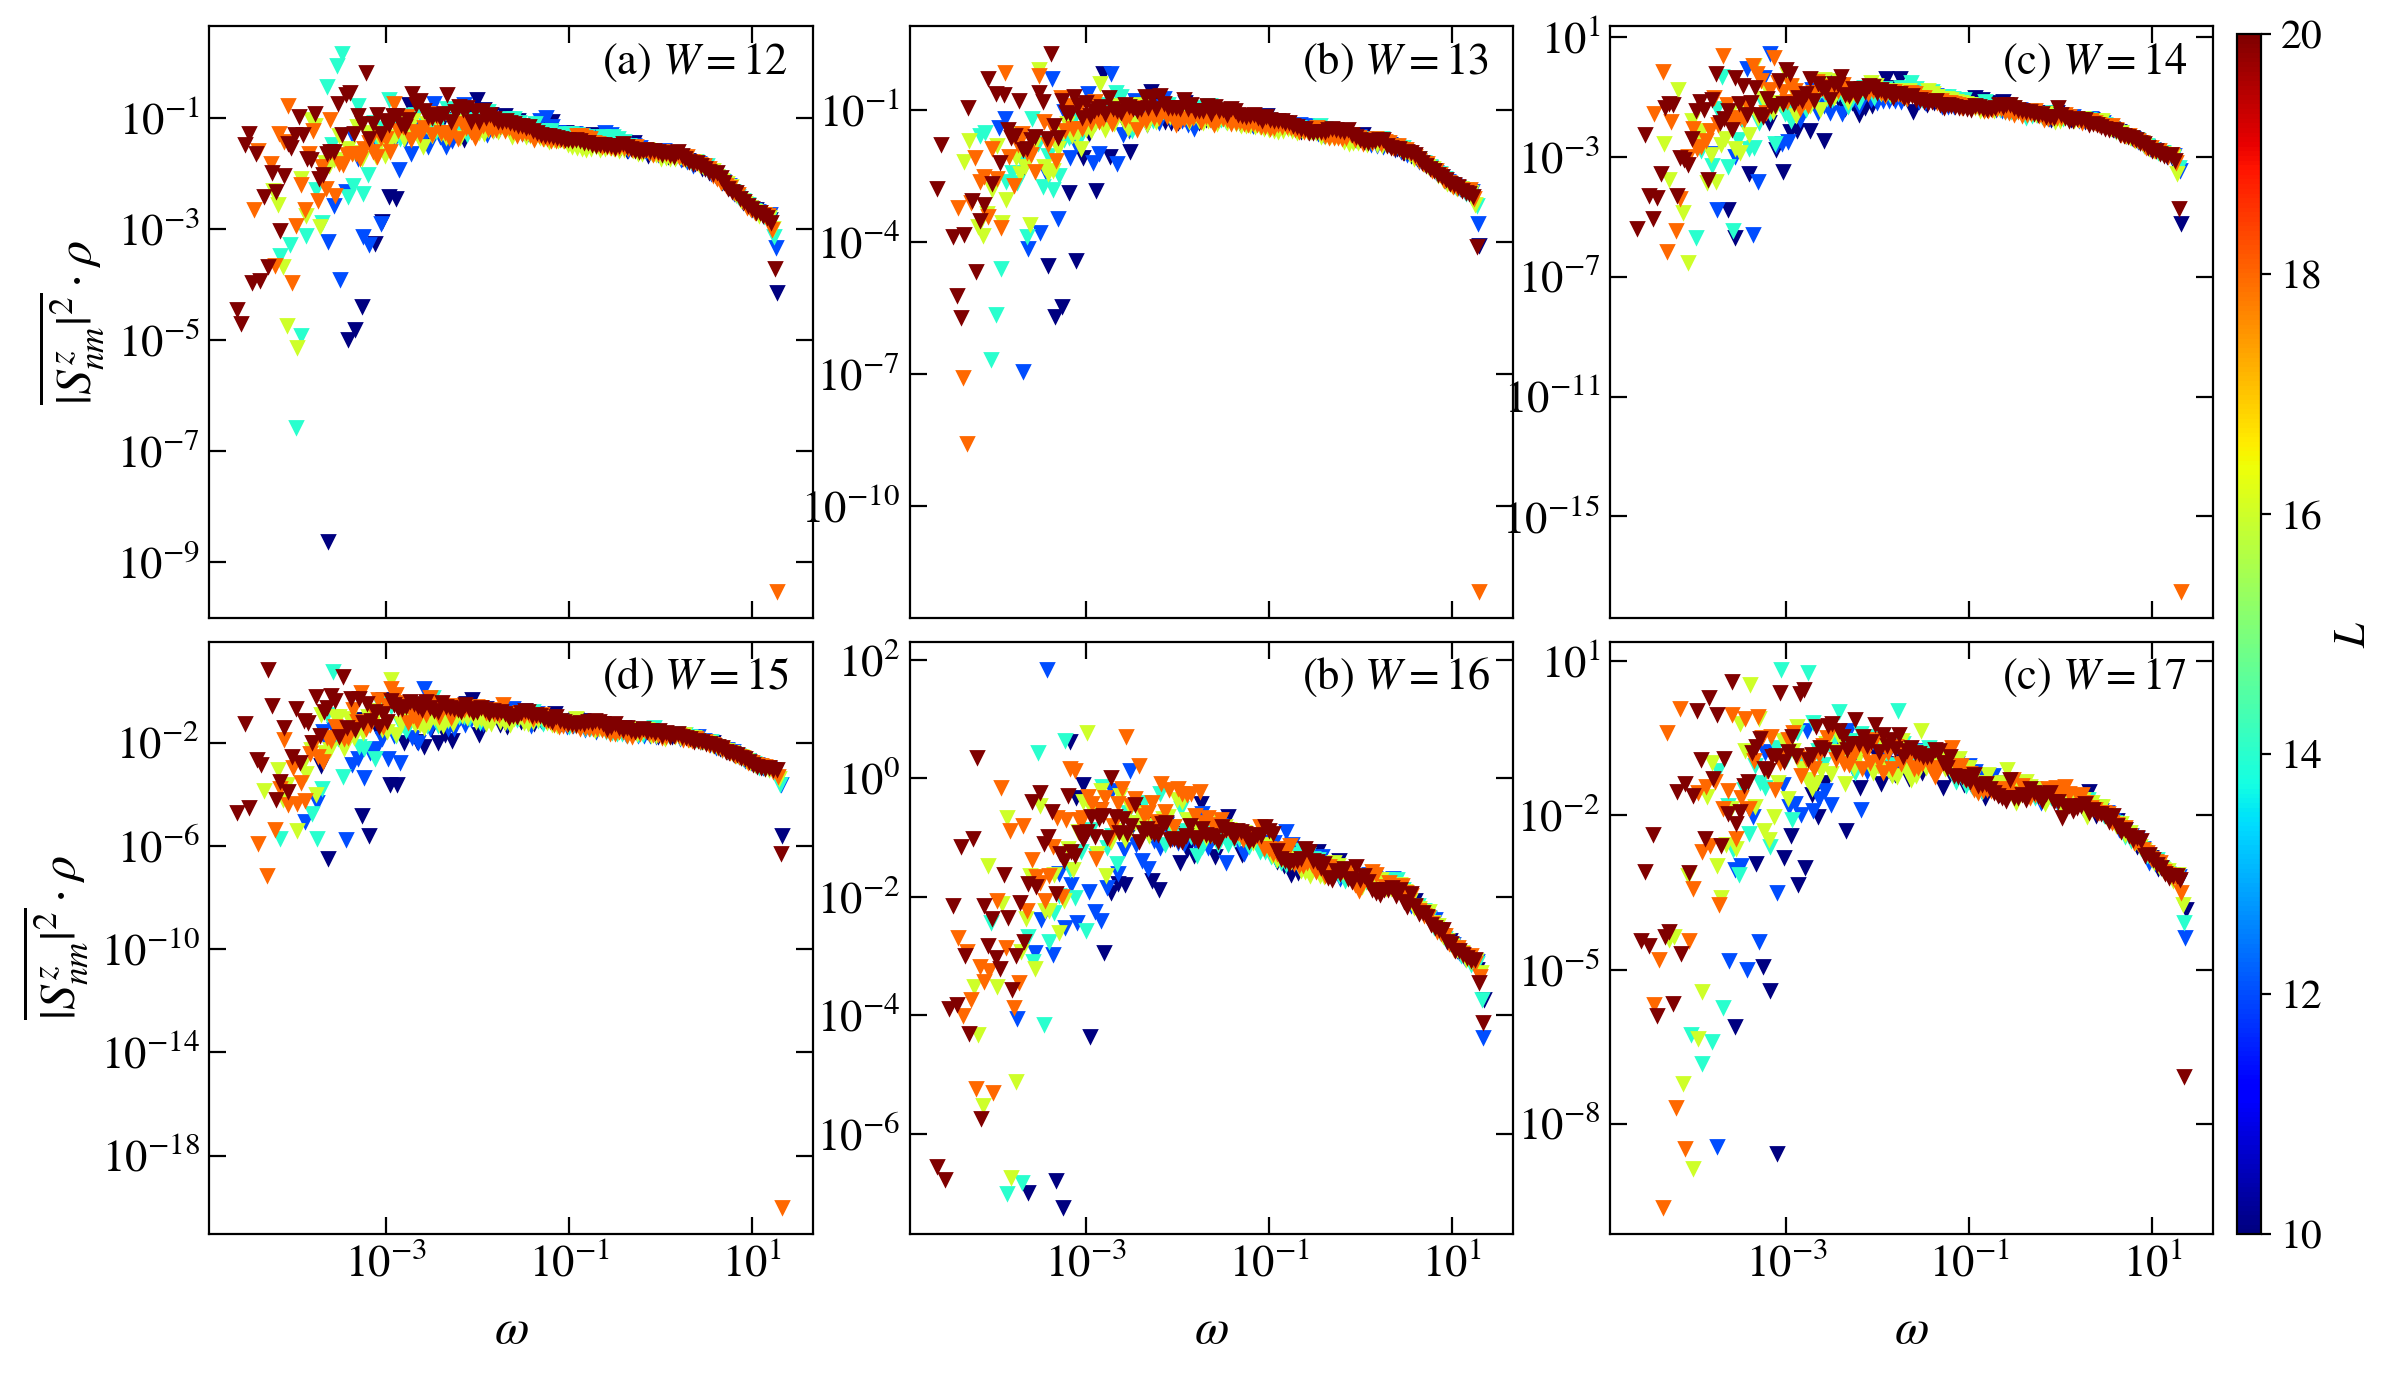

In [92]:
markers = itertools.cycle(markers_ls)
colors_ls_cyc = itertools.cycle(colors_ls)


L = 20
w = 12
J = 1
g = 1

DIM = 3
op=0
modello = 'Anderson'
prefix = base_dir(model=modello, d=DIM) + 'OrbitalsMatElem/'

sizes = np.arange(10, 21, 2) if DIM == 3 else np.arange(6, 12, 1)

def lorenz(x, A, G1):
    return A / ( (x / G1)**2 + 1)

def arctan(x, G):
    return 2 / np.pi * np.arctan(x / G)

AGP = 1
INTEGRATED = 0

E = np.arange(0.05, 0.95, 0.02)
omegax = np.zeros( (10 * (L)) )

labs = ["(a)", "(b)", "(c)", "(d)", "(b)", "(c)", "(d)"]
w_list = np.arange(12, 18, 1) if DIM == 3 else np.arange(26, 37, 2)
upper_cut = 100
ws = 100

# create a ScalarMappable and initialize a data structure
s_m = matplotlib.cm.ScalarMappable(cmap='jet', norm=matplotlib.colors.Normalize(vmin=min(sizes),vmax=max(sizes) ))
s_m.set_array([])

fig, axis = plt.subplots( nrows=2, ncols=3, figsize=(12,8), dpi = 200, sharex = True)
axis = np.array(axis).flatten()

E = np.arange(0.05, 0.95, 0.02)
omegax = np.zeros( (8 * (L)) )

upper_cut = 100

eps = 0.5

# insets = []
# for iie, gx in enumerate(gx_list[1:]):
#     inset = axis[iie].inset_axes([0.03, 0.08, 0.56, 0.56]) if iie == 0 else axis[iie].inset_axes([0.03, 0.08, 0.46, 0.46])
#     insets.append(inset)
    
for iie, wx in enumerate(w_list):
    # iie = iie2 - 1
    # if iie >= 1: inset = insets[iie]
    # elif iie < 0: inset = insets[0]
    cut = 0
    wH = np.zeros(sizes.shape)
    spec_at_wH = np.zeros(sizes.shape)
    for iiL, L in enumerate(sizes):
        col = s_m.to_rgba(L)
        dim = L**DIM
        name = prefix +  info(L=L, J=J, g=g, w=wx, model=modello, ext=',ws=%d.hdf5'%ws)
        if exists(name):
            with h5py.File(name, "r") as file:
                R = np.array(file.get('realisations'))
                
                Ex = np.array(file.get('energy_density'))
                idx = min(range(len(Ex)), key=lambda i: abs(Ex[i] - eps))
                # print(eps, Ex[idx2])
                DOS = np.array(file.get('count'))[idx] / R
                
                X = np.array(file.get('wH_typ_density'))[idx]
                wH[iiL] = X
                cut = X
                omegax = np.array(file.get('omegas'))
                omegax = np.sqrt(omegax[1:] * omegax[:-1])[0:]
                
                spec_fun = np.array(file.get('spec_fun'))[idx,0:] * DOS
                spec_fun_typ = np.array(file.get('spec_fun_typ'))[idx,0:] * DOS
                elem_count = np.array(file.get('element_count'))[idx,0:]
                
                # spec_fun = (spec_fun[:end_idx:3] * elem_count[:end_idx:3] + spec_fun[1:end_idx:3] * elem_count[1:end_idx:3] + spec_fun[2:end_idx:3] * elem_count[2:end_idx:3]) / (elem_count[:end_idx:3] + elem_count[1:end_idx:3] + elem_count[2:end_idx:3])
                # spec_fun_typ = (spec_fun_typ[:end_idx:3] * elem_count[:end_idx:3] + spec_fun_typ[1:end_idx:3] * elem_count[1:end_idx:3] + spec_fun_typ[2:end_idx:3] * elem_count[2:end_idx:3]) / (elem_count[:end_idx:3] + elem_count[1:end_idx:3] + elem_count[2:end_idx:3])
                # omegax = (omegax[:end_idx:3] + omegax[1:end_idx:3] + omegax[2:end_idx:3]) / 3
                # print(L, g, spec_fun.shape)
                
                wH_idx = min(range(len(omegax)), key=lambda i: abs(omegax[i] - wH[iiL]))
                spec_at_wH[iiL] = spec_fun[wH_idx]
                        
                yy0 = spec_fun if AGP else spec_fun_typ
                
                
                omegax = omegax[~np.isnan(yy0)]
                yy0 = yy0[~np.isnan(yy0)]
                
                if INTEGRATED:
                    xx = omegax
                    yy = integrate.cumulative_trapezoid(yy0, xx)
                    yy = (yy - yy[0]) / (yy[-1] - yy[0])
                    xx = xx[1:]
                else:
                    xx = omegax
                    yy = yy0
                # if iie2 == 0: inset.plot(xx, yy, color=col, marker='v', markersize=4, lw=0,zorder=0)
                # else:         
                axis[iie].plot(xx, yy, color=col, marker='v', markersize=4, lw=0,zorder=0)
                # axis[0][iie].axvline(x=upper_cut, ls=':', color='gray')
                # if not INTEGRATED: 
                #     indices = np.where(np.logical_and(omegax >= cut, omegax < upper_cut))[0]
                #     xx = omegax[indices]
                #     yy = yy0[indices]
                #     pars, pconv= fit(lorenz,
                #                 xdata = xx,
                #                 ydata = yy,
                #                 maxfev = 20000)
                #     z = np.logspace( np.log(min(xx)) + 4, np.log(max(xx))-2, 5000)
                #     # axis[iie].plot(z, lorenz(z, *pars), ls='--', color=col)
                #     G = np.abs(pars[-1]) if wx <= 16.54 else wH[iiL]
                #     # print(gx, L, G)
                # if iie > 0: inset.plot(xx / G, yy * G, color=col, marker='s', markersize=3, lw=0,zorder=20-L)
        else:
            print(name)

    ylab = r"$\overline{|S^z_{nm}|^2}\cdot\rho$" if AGP else r"$\overline{|S^z_{nm}|^2}^{\rm typ}\cdot\rho$"
    ylab2 = r"$\overline{|S^z_{nm}|^2}(\omega,\epsilon)$" if AGP else r"$\overline{|S^z_{nm}|^2}^{\rm typ}(\omega,\epsilon)$"
    # if gx >= 2: ylab = ylab2
    if iie >= 0:
        fig_help.set_plot_elements(axis[iie], ylabel=ylab if iie%3==0 else "", xlabel=r"$\omega$", font_size=16, set_legend=False, xscale='log', yscale='linear' if INTEGRATED else 'log')
    
        axis[iie].annotate(labs[iie] + r" $W=%g$"%wx, fontsize=16, xy=(0.65, 0.92), xycoords='axes fraction')
    # axis[iie].set_ylim(2e-8, None)
    # axis[0][iie].set_xlim(0.2*min(omegax), max(omegax))
    # print(gx, iie, iie2)
    if iie < 0:
        fig_help.set_plot_elements(inset, ylabel=r"$\overline{|S^z_{nm}|^2}\cdot\rho$", xlabel=r"$\omega$", font_size=12, set_legend=False, xscale='log', yscale='linear' if INTEGRATED else 'log')
    else:
        xlab = r"$\omega/\Gamma$" if iie == 1 else r"$\omega/\omega_H$"
        ylab = r"$\overline{|S^z_{nm}|^2}\cdot\rho\Gamma$" if iie == 1 else r"$\overline{|S^z_{nm}|^2}$"
        fig_help.set_plot_elements(inset, ylabel=ylab, xlabel=xlab, font_size=12, set_legend=False, xscale='log', yscale='linear' if INTEGRATED else 'log')
        
    # inset.xaxis.set_label_position("top")
    inset.xaxis.set_label_coords(.25, -0.04)
    # inset.xaxis.set_tick_params(pad=-20)

    inset.yaxis.set_label_position("right")
    inset.yaxis.set_label_coords(1.27, 0.4)
    inset.yaxis.tick_right()

fig.subplots_adjust(right=0.96)
cbar_ax = fig.add_axes([0.97, 0.125, 0.01, 0.75])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation='vertical')
cbar.set_label(r"$L$", fontsize=16)
cbar.ax.tick_params(labelsize=15)
cbar_ax.yaxis.set_ticks_position('right')
cbar_ax.yaxis.set_label_position('right')

fig.subplots_adjust(wspace = 0.16, hspace=0.04)

In [ ]:
|